

# Introduction

## Problem Definition

This project investigates the **impact of model quantization on anomaly detection in high-dimensional NLP embedding spaces**.

We focus on phishing email detection using precomputed text embeddings under a one-class anomaly detection setting:

* **Normal (ham) samples** are used for model training.
* **Phishing samples** are treated as anomalies and evaluated only at test time.
* Anomaly detection is performed using:

  * **Autoencoder (AE)** → Reconstruction Mean Squared Error (MSE)
  * **Gaussian Mixture Model (GMM)** → Negative Log-Likelihood (NLL)

This setup reflects a realistic anomaly detection scenario in which anomalous labels are unavailable during training and the model must learn the distribution of normal data.

The central research question is:

> Does reducing numeric precision (FP32 → FP16 / INT8 / INT4 / INT2) affect the reliability, calibration stability, ranking robustness, and interpretability of anomaly detection systems under deployment constraints?


## Why Quantization Matters in Anomaly Detection

Model quantization is widely adopted in industrial systems to:

* Reduce memory footprint
* Accelerate inference
* Enable deployment on edge or resource-constrained hardware

However, anomaly detection system are particularly sensitive to small numerical perturbations. Unlike standard classifiers that output class probabilities, anomaly detectors rely on:

* Precise reconstruction error magnitudes (Autoencoder)
* Accurate likelihood estimation (GMM)
* Threshold-based decision rules

Even minor perturbations in score distributions may:

* Shift anomaly rankings
* Break threshold calibration
* Change alert rates
* Alter feature attribution patterns (explainability)

Therefore, quantization may affect not only predictive accuracy, but also **decision stability, calibration reliability, and interpretability consistency**.


## Deployment Constraint: Fixed-FPR = 5%

To simulate a realistic industrial deployment scenario, we impose a **Fixed False Positive Rate (FPR) = 5% on normal (ham) training data**.

The anomaly threshold is selected as the 95th percentile of ham scores:

$$
\tau = \operatorname{quantile}\left(s_{\text{ham}},\, 0.95\right)
$$

This ensures that only 5% of normal samples are allowed to trigger alerts, controlling alert volume in deployment environments. Such fixed-FPR constraints are common in high-throughput security systems where false alarms must be tightly regulated.

We evaluate two scenarios:

1. **Same-threshold evaluation**
   Apply the FP32 threshold to quantized models.
   → Tests calibration break risk under quantization.

2. **Recalibrated-threshold evaluation**
   Recompute the threshold per quantized model using the same fixed-FPR constraint.
   → Tests performance recoverability after calibration.

This distinction allows us to separate:

* Score distribution shift
* Ranking instability
* True performance degradation



## Research Questions

This project aims to answer the following questions:

1. To what extent does quantization (FP32 → FP16 / INT8 / INT4 / INT2) degrade anomaly detection performance?
2. Does quantization alter score distributions and break threshold calibration?
3. How stable are anomaly rankings under reduced precision?
4. Which model layers are most sensitive to quantization?
5. Does quantization affect SHAP-based feature importance and interpretability stability?
6. Can Quantization-Aware Training (QAT) mitigate performance degradation compared to Post-Training Quantization (PTQ), particularly at INT8 and INT4 precision levels?
7. Does embedding dimensionality (1024 vs 384) influence quantization robustness in anomaly detection systems, and does higher representational capacity provide structural resistance to precision-induced perturbations?



# Environment & Library Imports

This section imports all required libraries used throughout the notebook.

Libraries are grouped by:
- Core utilities
- PyTorch (modeling and quantization)
- Scikit-learn (metrics and GMM)
- Scientific utilities
- Visualization
- Explainability (SHAP)

Centralizing imports improves readability and reproducibility.

In [80]:
# Global Imports

# Core
import os
import copy
import numpy as np
import pandas as pd

# PyTorch 
import torch
import torch.nn as nn
import torch.ao.quantization as tq
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn 
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

# Scientific Utilities 
from scipy.special import logsumexp
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

# Visualization 
import matplotlib.pyplot as plt

#Explainability 
import shap

# Display Utilities
from IPython.display import display, Markdown


# Device Configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


# 2️ Dataset & Embeddings

## Dataset Description

We use an email phishing detection dataset containing:

- **Label 0 → Normal (ham)**
- **Label 1 → Phishing / Spam (anomaly)**

### Anomaly Detection Protocol

- Training uses **only normal (ham)** samples.
- Testing uses **both normal and phishing** samples.
- The models learn the distribution of normal data.
- Phishing emails are detected as deviations from this learned distribution.

This reflects a realistic anomaly detection setting where anomaly labels are not available during training.


## Embedding Representations

We operate in high-dimensional embedding space instead of raw text.

Two embedding types are used:

• **BGE embeddings** (dimension = 1024)  
• **MiniLM embeddings** (dimension = 384)

All embeddings are:

- Precomputed
- Stored as NumPy arrays
- L2-normalized (mean L2 norm ≈ 1)

This allows us to isolate **numerical precision effects** from text preprocessing variability.


## Data Statistics

For each embedding set we report:

- Training shape (ham-only)
- Test shape (ham + phishing)
- Anomaly percentage
- Mean L2 norm

These checks ensure consistency before running experiments.

##  Embedding Generation Overview

All embeddings used in this study were generated by me from raw email text.  
Full preprocessing and embedding details are available here:

📎 **Embedding notebook:**  
[datasettoembedding.ipynb](datasettoembedding.ipynb)

### Key Steps

- Cleaned raw emails (removed empty and extreme-length texts)
- Trained in anomaly-detection setting (ham-only training)
- Generated embeddings using:
  - **BGE-large-en-v1.5** (1024-d)
  - **all-MiniLM-L6-v2** (384-d)
- Applied **L2 normalization** (`‖x‖₂ ≈ 1`)
- Stored embeddings as `float32` NumPy arrays

### Why This Matters

- L2 normalization places embeddings on a **unit hypersphere**, ensuring consistent scale.
- This makes geometric relationships (angles, cosine similarity) meaningful.
- Under quantization, small numeric perturbations can distort angular structure, affecting:
  - Reconstruction error (Autoencoder)
  - Likelihood estimation (GMM)

Using **two embedding dimensions (1024 vs 384)** allows us to analyze whether representation dimensionality influences quantization robustness.

### 1. Loading Precomputed Embeddings

In this section, we load the precomputed embedding datasets and perform basic consistency checks.

For each embedding representation (BGE-1024 and MiniLM-384), we verify:

- Training set shape (ham-only samples)
- Test set shape (ham + phishing samples)
- Embedding dimensionality
- Anomaly ratio in the test set
- Mean L2 norm (to confirm normalization)

These checks ensure that the embedding space is correctly constructed and numerically consistent before running anomaly detection experiments.

In [81]:
# Dataset & Embeddings
# Load embeddings + basic sanity checks
#  Helper function 
def load_embeddings(train_path: str, test_path: str, label_path: str):
    """
    Load precomputed embedding datasets.

    Parameters:
        train_path  : Path to ham-only training embeddings
        test_path   : Path to mixed (ham + phishing) test embeddings
        label_path  : Path to test labels

    Returns:
        X_train (float32)
        X_test  (float32)
        y_test  (int64)
    """
    X_train = np.load(train_path).astype(np.float32)
    X_test  = np.load(test_path).astype(np.float32)
    y_test  = np.load(label_path).astype(np.int64)

    return X_train, X_test, y_test


#  Dataset configuration 
DATASETS = {
    "BGE-1024": {
        "dimension": 1024,
        "train_path": "phishing_bge_1024_train.npy",
        "test_path":  "phishing_bge_1024_test.npy",
        "label_path": "phishing_bge_1024_y_test.npy",
    },
    "MiniLM-384": {
        "dimension": 384,
        "train_path": "phishing_minilm_384_train.npy",
        "test_path":  "phishing_minilm_384_test.npy",
        "label_path": "phishing_minilm_384_y_test.npy",
    }
}


# Load + print statistics
for dataset_name, config in DATASETS.items():

    X_train, X_test, y_test = load_embeddings(
        config["train_path"],
        config["test_path"],
        config["label_path"]
    )

    print("\n===================================")
    print(f"Dataset: {dataset_name}")
    print("-----------------------------------")

    print("Train shape (ham only):", X_train.shape)
    print("Test shape  (mixed)   :", X_test.shape)
    print("Embedding dimension   :", config["dimension"])
    print("Phishing ratio (test) :", round(float(y_test.mean()), 4))

    # L2 norm sanity check (embeddings should be normalized)
    print("Mean L2 norm (train)  :", float(np.linalg.norm(X_train, axis=1).mean()))
    print("Mean L2 norm (test)   :", float(np.linalg.norm(X_test, axis=1).mean()))


Dataset: BGE-1024
-----------------------------------
Train shape (ham only): (37808, 1024)
Test shape  (mixed)   : (79978, 1024)
Embedding dimension   : 1024
Phishing ratio (test) : 0.5273
Mean L2 norm (train)  : 1.0
Mean L2 norm (test)   : 1.0

Dataset: MiniLM-384
-----------------------------------
Train shape (ham only): (37808, 384)
Test shape  (mixed)   : (79978, 384)
Embedding dimension   : 384
Phishing ratio (test) : 0.5273
Mean L2 norm (train)  : 1.0
Mean L2 norm (test)   : 1.0


### PCA Visualization of Embedding Space

To qualitatively inspect the geometric structure of the embedding space, we project a subset of test samples onto a 2D plane using Principal Component Analysis (PCA).

This visualization helps assess:

- Whether ham and phishing samples exhibit partial separation
- The degree of overlap between normal and anomalous data
- The intrinsic structure of high-dimensional embeddings

Since PCA is used only for visualization, it does not affect model training or evaluation.

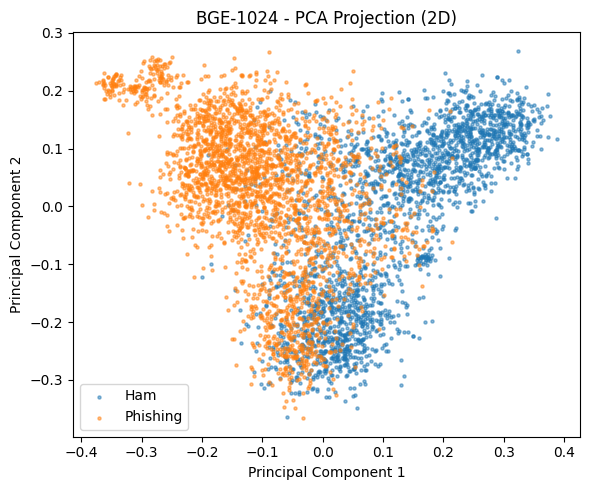

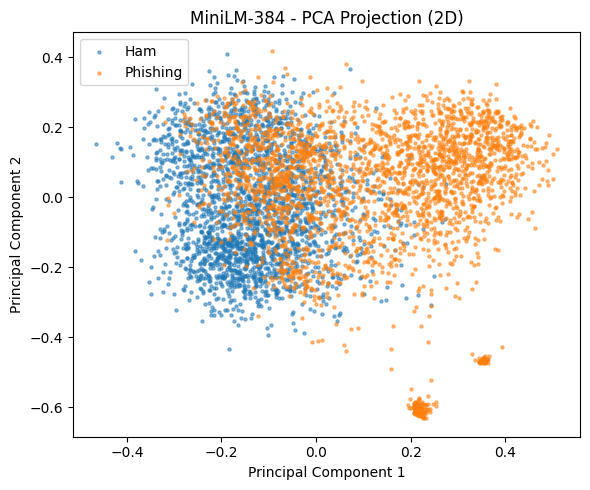

In [82]:
# Section 2: PCA Visualization
for dataset_name, config in DATASETS.items():

    X_train, X_test, y_test = load_embeddings(
        config["train_path"],
        config["test_path"],
        config["label_path"]
    )

    # Random subset for visualization (avoid ordering bias)
    n_visualization = 5000
    rng = np.random.default_rng(seed=42)
    indices = rng.choice(len(X_test), size=n_visualization, replace=False)

    X_subset = X_test[indices]
    y_subset = y_test[indices]

    # PCA projection
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_subset)

    # Plot
    plt.figure(figsize=(6, 5))

    plt.scatter(
        X_2d[y_subset == 0, 0],
        X_2d[y_subset == 0, 1],
        s=5, alpha=0.5, label="Ham"
    )

    plt.scatter(
        X_2d[y_subset == 1, 0],
        X_2d[y_subset == 1, 1],
        s=5, alpha=0.5, label="Phishing"
    )

    plt.title(f"{dataset_name} - PCA Projection (2D)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

### PCA Analysis and Geometric Interpretation

The 2D PCA projections provide a qualitative view of the embedding geometry for both BGE-1024 and MiniLM-384 representations.

Several observations can be made:

1. **Partial Separation**
   Ham and phishing samples exhibit visible clustering tendencies, but there is significant overlap between the two classes. This confirms that the task is non-trivial and cannot be solved by simple linear separation in low-dimensional space.

2. **Structured Manifolds**
   Both embedding spaces show structured, multi-modal distributions rather than random scatter. This suggests that the embeddings encode meaningful semantic structure, which anomaly detection models can exploit.

3. **Higher-Dimensional Effects**
   The BGE-1024 embedding appears slightly more geometrically structured, potentially reflecting higher representational capacity. In contrast, MiniLM-384 shows tighter but more overlapping clusters, possibly indicating reduced redundancy in lower-dimensional space.

4. **Implication for Anomaly Detection**
   The visible overlap between ham and phishing points justifies the use of distribution-based anomaly detection (AE and GMM) rather than simple boundary-based classification. Since anomalies are not linearly separable, modeling the normal distribution is a more appropriate strategy.

It is important to note that PCA is used purely for visualization. The anomaly detection models operate in the full high-dimensional embedding space.

### Cosine Similarity Analysis

To better understand the geometric structure of the embedding space, we computed cosine similarity statistics between:

- Ham–Ham pairs (normal–normal)
- Phishing–Phishing pairs (anomaly–anomaly)
- Ham–Phishing pairs (normal–anomaly)

Since embeddings are L2-normalized (‖x‖₂ ≈ 1), cosine similarity directly measures angular proximity.

Across both embedding representations, the most important observation is:

> **Mean(Ham–Ham) > Mean(Ham–Phishing)**

For example (BGE-1024):
- Mean(Ham–Ham) = **0.551**
- Mean(Ham–Phishing) = **0.515**

This indicates that normal emails form a more coherent region in embedding space, while phishing samples are geometrically more separated from normal data.

This structural property justifies the use of distribution-based anomaly detection models (Autoencoder and GMM), which rely on learning the compact manifold of normal samples.

In [83]:
# Cosine Similarity (Key Separation Metric)
def cosine_separation_metric(X, y, n_samples=2000, random_state=42):

    rng = np.random.default_rng(random_state)

    idx_ham = np.where(y == 0)[0]
    idx_phish = np.where(y == 1)[0]

    idx_ham_sample = rng.choice(idx_ham, size=min(n_samples, len(idx_ham)), replace=False)
    idx_phish_sample = rng.choice(idx_phish, size=min(n_samples, len(idx_phish)), replace=False)

    X_ham = X[idx_ham_sample]
    X_phish = X[idx_phish_sample]

    sim_ham = cosine_similarity(X_ham)
    sim_cross = cosine_similarity(X_ham, X_phish)

    # Remove self-similarity
    ham_vals = sim_ham[np.triu_indices_from(sim_ham, k=1)]
    cross_vals = sim_cross.flatten()

    mean_ham = float(np.mean(ham_vals))
    mean_cross = float(np.mean(cross_vals))

    return mean_ham, mean_cross, mean_ham - mean_cross


# Run for both datasets
rows = []

for dataset_name, config in DATASETS.items():

    X_train, X_test, y_test = load_embeddings(
        config["train_path"],
        config["test_path"],
        config["label_path"]
    )

    mean_ham, mean_cross, separation = cosine_separation_metric(X_test, y_test)

    rows.append({
        "Dataset": dataset_name,
        "Mean(Ham–Ham)": mean_ham,
        "Mean(Ham–Phishing)": mean_cross,
        "Separation Gap": separation
    })

cosine_summary = pd.DataFrame(rows)
display(cosine_summary)

,Dataset,Mean(Ham–Ham),Mean(Ham–Phishing),Separation Gap
0,BGE-1024,0.551457,0.514911,0.036546
1,MiniLM-384,0.212350,0.175744,0.036606


### PCA Explained Variance Interpretation

The cumulative explained variance curves show that both embedding spaces retain substantial high-dimensional structure.

For BGE-1024, the first 50 principal components explain approximately 50% of the variance, indicating that information is distributed across many directions in embedding space.

For MiniLM-384, the first 50 components explain nearly 60% of the variance, suggesting slightly stronger variance concentration and potentially lower intrinsic dimensionality.

This difference is relevant for quantization robustness:
- More evenly distributed variance (BGE-1024) suggests higher representational spread.
- More concentrated variance (MiniLM-384) may imply reduced redundancy and increased sensitivity to precision reduction.

Importantly, neither embedding collapses to a low-dimensional manifold, supporting the need for high-dimensional anomaly modeling.

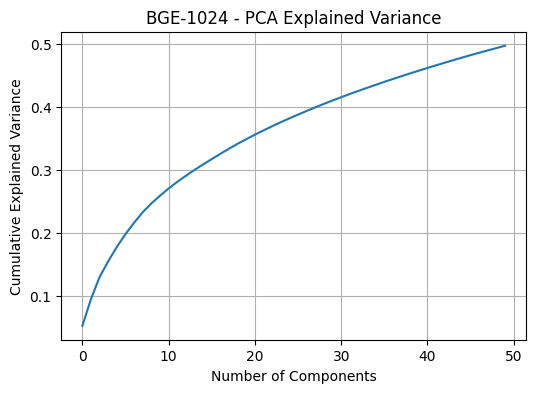

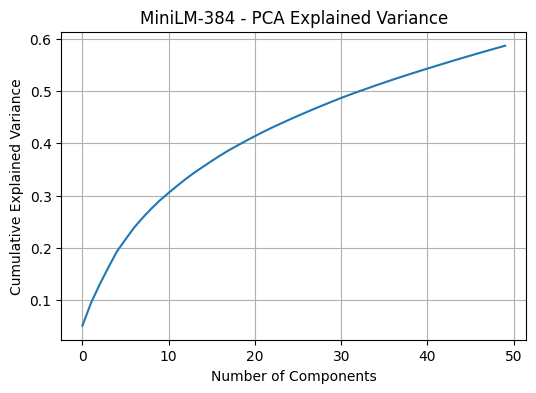

In [84]:
for dataset_name, config in DATASETS.items():
    X_train, X_test, y_test = load_embeddings(
        config["train_path"],
        config["test_path"],
        config["label_path"]
    )

    pca = PCA(n_components=50)
    pca.fit(X_test)

    cumulative_var = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(6,4))
    plt.plot(cumulative_var)
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title(f"{dataset_name} - PCA Explained Variance")
    plt.grid(True)
    plt.show()

#  FP32 Baseline Model

Before analyzing quantization effects, we establish full-precision (FP32) baselines.

We evaluate two anomaly detection models operating directly in embedding space. These baselines serve as reference systems for performance comparison, calibration analysis, score drift evaluation, and ranking stability assessment.


##  Autoencoder (AE)

The Autoencoder (AE) is trained to reconstruct normal (ham) embeddings. It learns a compressed latent representation of normal data and measures reconstruction error as an anomaly signal.

**Key properties:**

- Input: embedding vector of dimension **D**
- Bottleneck: latent representation **z**
- Loss: Mean Squared Error (MSE)
- Anomaly score: reconstruction MSE

**Intuition:**  
If a test sample deviates from the learned normal distribution, its reconstruction error increases.


### Architecture Overview

The Autoencoder is a fully connected symmetric architecture.

For an input embedding of dimension **D**, the structure is:

**Encoder**
- Linear(D → h₁)
- ReLU
- Linear(h₁ → h₂)
- ReLU
- Linear(h₂ → z)

**Decoder (symmetric)**
- Linear(z → h₂)
- ReLU
- Linear(h₂ → h₁)
- ReLU
- Linear(h₁ → D)


### Dimensional Configuration

- For **BGE-1024**:
  - h₁ = 512  
  - h₂ = 256  

- For **MiniLM-384**:
  - h₁ = 256  
  - h₂ = 128  

- Latent dimension: **z = 64**

Total structure:
- 3 encoder layers
- 3 decoder layers
- 6 linear layers
- ReLU activations (except final output layer)


### Forward Mapping

The encoder compresses the input:

$$
z = f_\theta(x)
$$

The decoder reconstructs the embedding:

$$
\hat{x} = g_\phi(z)
$$

The full mapping is:

$$
\hat{x} = g_\phi(f_\theta(x))
$$


### Training Objective

The model is trained using Mean Squared Error:

$$
\mathcal{L}(x) = \|x - \hat{x}\|_2^2
$$

where:
- $x$ is the input embedding  
- $\hat{x}$ is the reconstructed embedding  


### Anomaly Scoring

At inference time, the anomaly score is defined as:

$$
\text{score}(x) = \|x - \hat{x}\|_2^2
$$

Samples with higher reconstruction error are considered more likely to be anomalous.

In [85]:
class Autoencoder(nn.Module):
    """
    Fully-connected Autoencoder.
    Architecture adapts to embedding dimension.
    """
    def __init__(self, input_dim: int, latent_dim: int = 64):
        super().__init__()

        hidden_1 = 256 if input_dim == 384 else 512
        hidden_2 = 128 if input_dim == 384 else 256

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_1), nn.ReLU(),
            nn.Linear(hidden_1, hidden_2), nn.ReLU(),
            nn.Linear(hidden_2, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_2), nn.ReLU(),
            nn.Linear(hidden_2, hidden_1), nn.ReLU(),
            nn.Linear(hidden_1, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_autoencoder_fp32(X_train, input_dim, epochs=10, lr=1e-3, batch_size=256):

    model = Autoencoder(input_dim=input_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    dataset = TensorDataset(torch.from_numpy(X_train))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()

    for epoch in range(epochs):
        total_loss = 0.0

        for (batch_x,) in loader:
            batch_x = batch_x.to(DEVICE)

            optimizer.zero_grad()
            reconstruction = model(batch_x)
            loss = loss_fn(reconstruction, batch_x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_x.size(0)

        print(f"Epoch {epoch+1}/{epochs} | MSE: {total_loss / len(X_train):.6f}")

    return model.eval()


@torch.no_grad()
def compute_ae_scores(model, X, batch_size=1024):

    model.eval()

    scores = []

    loader = DataLoader(
        TensorDataset(torch.from_numpy(X)),
        batch_size=batch_size,
        shuffle=False
    )

    for (batch_x,) in loader:
        batch_x = batch_x.to(DEVICE).float()
        reconstruction = model(batch_x)
        mse = torch.mean((reconstruction - batch_x) ** 2, dim=1)
        scores.append(mse.cpu().numpy())

    return np.concatenate(scores)

In [86]:
# Train FP32 Autoencoders (Store Baselines)

ae_fp32_models = {}
ae_fp32_scores = {}

for dataset_name, config in DATASETS.items():

    X_train, X_test, y_test = load_embeddings(
        config["train_path"],
        config["test_path"],
        config["label_path"]
    )

    epochs = 8 if config["dimension"] == 384 else 10

    print(f"\nTraining AE (FP32) - {dataset_name}")
    ae_model = train_autoencoder_fp32(
        X_train,
        input_dim=config["dimension"],
        epochs=epochs
    )

    scores_test = compute_ae_scores(ae_model, X_test)

    ae_fp32_models[dataset_name] = ae_model
    ae_fp32_scores[dataset_name] = {
        "scores_test": scores_test,
        "y_test": y_test
    }


Training AE (FP32) - BGE-1024
Epoch 1/10 | MSE: 0.000434
Epoch 2/10 | MSE: 0.000330
Epoch 3/10 | MSE: 0.000294
Epoch 4/10 | MSE: 0.000273
Epoch 5/10 | MSE: 0.000259
Epoch 6/10 | MSE: 0.000248
Epoch 7/10 | MSE: 0.000239
Epoch 8/10 | MSE: 0.000232
Epoch 9/10 | MSE: 0.000226
Epoch 10/10 | MSE: 0.000221

Training AE (FP32) - MiniLM-384
Epoch 1/8 | MSE: 0.001763
Epoch 2/8 | MSE: 0.001203
Epoch 3/8 | MSE: 0.001052
Epoch 4/8 | MSE: 0.000966
Epoch 5/8 | MSE: 0.000911
Epoch 6/8 | MSE: 0.000871
Epoch 7/8 | MSE: 0.000845
Epoch 8/8 | MSE: 0.000824


In [87]:
summary_rows = []

for dataset_name, results in ae_fp32_scores.items():

    test_scores = results["scores_test"]
    y_test = results["y_test"]

    scores_ham = test_scores[y_test == 0]
    scores_phishing = test_scores[y_test == 1]

    # Core ranking metrics
    auroc = roc_auc_score(y_test, test_scores)
    pr_auc = average_precision_score(y_test, test_scores)

    # Distribution separation
    mean_ham = scores_ham.mean()
    mean_phishing = scores_phishing.mean()
    separation_gap = mean_phishing - mean_ham

    summary_rows.append({
        "Dataset": dataset_name,
        "AUROC": round(auroc, 4),
        "PR-AUC": round(pr_auc, 4),
        "Mean MSE (Ham)": round(mean_ham, 6),
        "Mean MSE (Phishing)": round(mean_phishing, 6),
        "Mean Separation Gap": round(separation_gap, 6)
    })

ae_fp32_summary = pd.DataFrame(summary_rows)
ae_fp32_summary

,Dataset,AUROC,PR-AUC,Mean MSE (Ham),Mean MSE (Phishing),Mean Separation Gap
0,BGE-1024,0.889600,0.889800,0.000218,0.000318,0.000100
1,MiniLM-384,0.822700,0.832500,0.000811,0.001192,0.000380


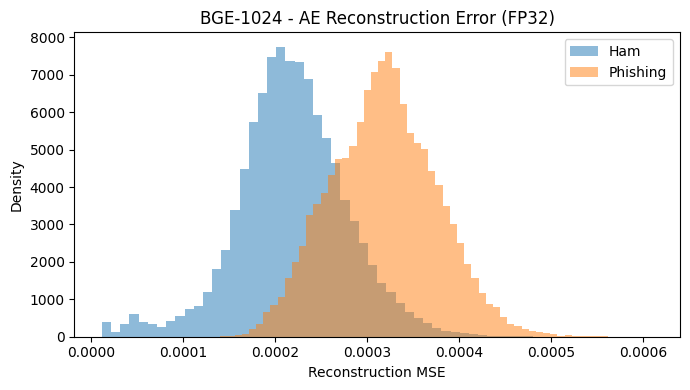

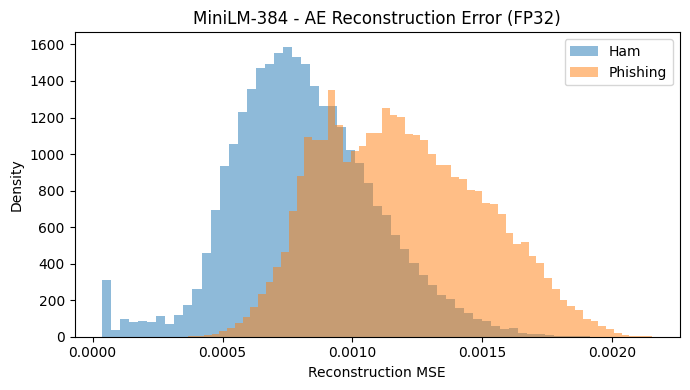

In [88]:
# ============================================
# AE Score Distribution (FP32)
# ============================================

for dataset_name in ae_fp32_scores:

    scores_test = ae_fp32_scores[dataset_name]["scores_test"]
    y_test = ae_fp32_scores[dataset_name]["y_test"]

    plt.figure(figsize=(7, 4))

    plt.hist(scores_test[y_test == 0], bins=60, alpha=0.5,
             density=True, label="Ham")

    plt.hist(scores_test[y_test == 1], bins=60, alpha=0.5,
             density=True, label="Phishing")

    plt.title(f"{dataset_name} - AE Reconstruction Error (FP32)")
    plt.xlabel("Reconstruction MSE")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

### FP32 Autoencoder Score Distribution Analysis

The histograms above show the reconstruction error (MSE) distributions for ham (normal) and phishing (anomalous) samples under full precision (FP32).

Several key observations can be made:

1. **Clear Rightward Shift for Phishing**
   In both embedding representations (BGE-1024 and MiniLM-384), phishing samples exhibit systematically higher reconstruction errors than ham samples.  
   This confirms that the Autoencoder successfully models the normal data distribution and struggles to reconstruct anomalous inputs.

2. **Partial Overlap Between Distributions**
   Although phishing scores are generally higher, there is visible overlap between the two distributions.  
   This overlap explains why perfect separation is not achievable and motivates the need for threshold-based decision rules under a fixed-FPR constraint.

3. **Embedding Dimensionality Effect**
   - The BGE-1024 model produces lower absolute MSE values and slightly sharper separation.
   - The MiniLM-384 model exhibits higher reconstruction errors overall, reflecting reduced representational redundancy in lower-dimensional embeddings.

4. **Suitability for Fixed-FPR Calibration**
   The ham distribution appears compact and unimodal, which is desirable for percentile-based threshold selection.  
   This makes the 95th percentile threshold (Fixed-FPR = 5%) well-defined and stable in the FP32 baseline.

Overall, these results validate the FP32 Autoencoder as a meaningful reference model for subsequent quantization experiments.

# Gaussian Mixture Model (FP32 Baseline)

We model the distribution of **normal (ham) embeddings** using a Gaussian Mixture Model (GMM) with diagonal covariance.

The GMM is trained **only on ham samples** (one-class setup) to learn the normal data manifold.


## Model Configuration

- **Number of components (K):** 8  
- **Covariance type:** Diagonal  
- **Regularization:** `reg_covar = 1e-6`  
- **Maximum iterations:** 300  


## Why Diagonal Covariance?

Diagonal covariance is chosen because:

-  It **reduces parameter count** in high-dimensional embeddings  
-  It improves **numerical stability**  
-  It mitigates **overfitting risk**  
-  It scales better for 384–1024 dimensional embedding spaces  

In high-dimensional NLP embeddings, full covariance would require learning \( O(d^2) \) parameters per component, which is computationally unstable and memory-intensive.


## Anomaly Score Definition

The anomaly score is defined as the **Negative Log-Likelihood (NLL)** under the learned mixture distribution:

$$
\text{score}(x) = -\log p(x)
$$
Where:

- $p(x)$  is the likelihood under the trained GMM  
- Lower likelihood → Higher anomaly score  
- Higher likelihood → More normal sample  



In [89]:
# ============================================
# 3.2 Gaussian Mixture Model (FP32 Baseline)
# ============================================

from sklearn.mixture import GaussianMixture
from scipy.special import logsumexp
import numpy as np
import matplotlib.pyplot as plt


def fit_gmm_fp32(X_train, n_components=8):
    """
    Fit diagonal-covariance GMM on ham-only data.
    """
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="diag",
        max_iter=300,
        reg_covar=1e-6,
        random_state=42
    )
    gmm.fit(X_train)
    return gmm


def compute_gmm_nll(X, weights, means, variances):
    """
    Compute Negative Log-Likelihood (NLL)
    under diagonal-covariance GMM.
    """
    X = X.astype(np.float64)
    weights = weights.astype(np.float64)
    means = means.astype(np.float64)
    variances = variances.astype(np.float64)

    eps = 1e-12
    K, D = means.shape

    log_weights = np.log(weights + eps)
    log_det = np.sum(np.log(variances + eps), axis=1)
    constant = D * np.log(2.0 * np.pi)

    diff = X[:, None, :] - means[None, :, :]
    mahalanobis = np.sum((diff**2) / (variances[None, :, :] + eps), axis=2)

    log_components = (
        log_weights[None, :]
        - 0.5 * (constant + log_det[None, :] + mahalanobis)
    )

    log_prob = logsumexp(log_components, axis=1)

    return -log_prob  # anomaly score

In [90]:
# ============================================
# Train FP32 GMM Models (Store Baselines)
# ============================================

gmm_fp32_models = {}
gmm_fp32_scores = {}

for dataset_name, config in DATASETS.items():

    X_train, X_test, y_test = load_embeddings(
        config["train_path"],
        config["test_path"],
        config["label_path"]
    )

    print(f"\nFitting GMM (FP32) - {dataset_name}")

    gmm_model = fit_gmm_fp32(X_train, n_components=8)

    scores_test = compute_gmm_nll(
        X_test,
        gmm_model.weights_,
        gmm_model.means_,
        gmm_model.covariances_
    )

    gmm_fp32_models[dataset_name] = gmm_model
    gmm_fp32_scores[dataset_name] = {
        "scores_test": scores_test,
        "y_test": y_test
    }


Fitting GMM (FP32) - BGE-1024

Fitting GMM (FP32) - MiniLM-384


In [91]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

summary_rows = []

for dataset_name, results in gmm_fp32_scores.items():

    test_scores = results["scores_test"]
    y_test = results["y_test"]

    scores_ham = test_scores[y_test == 0]
    scores_phishing = test_scores[y_test == 1]

    # Core ranking metrics
    auroc = roc_auc_score(y_test, test_scores)
    pr_auc = average_precision_score(y_test, test_scores)

    # Distribution separation
    mean_ham = scores_ham.mean()
    mean_phishing = scores_phishing.mean()
    separation_gap = mean_phishing - mean_ham

    summary_rows.append({
        "Dataset": dataset_name,
        "AUROC": round(auroc, 4),
        "PR-AUC": round(pr_auc, 4),
        "Mean NLL (Ham)": round(mean_ham, 2),
        "Mean NLL (Phishing)": round(mean_phishing, 2),
        "Mean Separation Gap": round(separation_gap, 2)
    })

gmm_fp32_summary = pd.DataFrame(summary_rows)
gmm_fp32_summary

,Dataset,AUROC,PR-AUC,Mean NLL (Ham),Mean NLL (Phishing),Mean Separation Gap
0,BGE-1024,0.851700,0.827400,-2602.970000,-2461.570000,141.400000
1,MiniLM-384,0.821200,0.784700,-691.090000,-643.960000,47.120000


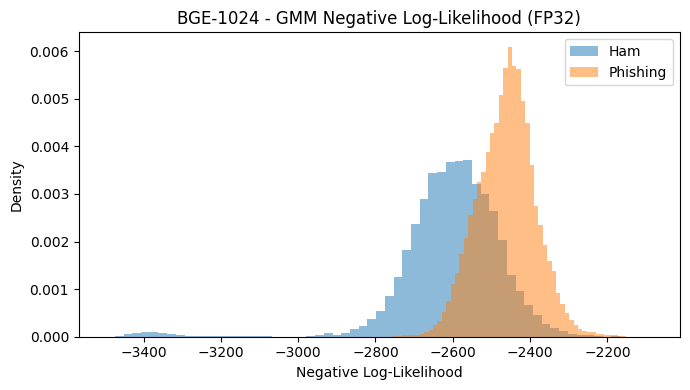

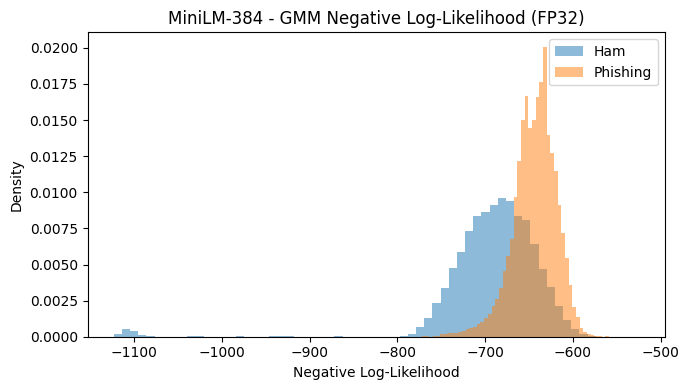

In [92]:
# GMM Score Distribution (FP32)

for dataset_name in gmm_fp32_scores:

    scores_test = gmm_fp32_scores[dataset_name]["scores_test"]
    y_test = gmm_fp32_scores[dataset_name]["y_test"]

    plt.figure(figsize=(7, 4))

    plt.hist(scores_test[y_test == 0], bins=60, alpha=0.5,
             density=True, label="Ham")

    plt.hist(scores_test[y_test == 1], bins=60, alpha=0.5,
             density=True, label="Phishing")

    plt.title(f"{dataset_name} - GMM Negative Log-Likelihood (FP32)")
    plt.xlabel("Negative Log-Likelihood")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

### GMM Score Distribution Analysis (FP32 Baseline)

The histograms above illustrate the distribution of Negative Log-Likelihood (NLL) scores
for ham (normal) and phishing (anomalous) samples under the FP32 GMM baseline.

#### Key Observations

1. **Distribution Shift**
   In both embedding spaces, phishing samples exhibit systematically higher anomaly scores
   (less negative NLL values) compared to ham samples.  
   This indicates that the GMM successfully captures the structure of the normal data distribution.

2. **Partial Overlap**
   Although the distributions are clearly shifted, there remains overlap between ham and phishing.
   This confirms that the task is non-trivial and cannot be solved by simple linear separation.

3. **Embedding Dimensionality Effect**
   - The BGE-1024 representation shows stronger separation between the two score distributions.
   - MiniLM-384 exhibits a more compact but more overlapping structure.

   This observation is consistent with the AUROC results reported earlier,
   suggesting that higher-dimensional embeddings allow more expressive density modeling.

4. **Baseline Validity**
   The visible separation, combined with realistic overlap, confirms that the FP32 GMM
   provides a stable and meaningful baseline for subsequent quantization analysis.

Overall, the FP32 GMM demonstrates meaningful anomaly separability while preserving
realistic distribution overlap, making it suitable for evaluating the effects of reduced precision.

In [93]:
# ============================================
# GMM Parameter Count (Informational)
# ============================================

def print_gmm_parameter_count(gmm_model):
    K, D = gmm_model.means_.shape
    n_means = K * D
    n_variances = K * D
    n_weights = K
    total = n_means + n_variances + n_weights

    print(f"GMM parameters: {total:,} (means + variances + weights)")


for dataset_name, gmm_model in gmm_fp32_models.items():
    print(f"\n{dataset_name}")
    print_gmm_parameter_count(gmm_model)


BGE-1024
GMM parameters: 16,392 (means + variances + weights)

MiniLM-384
GMM parameters: 6,152 (means + variances + weights)


### Baseline Model Verification (FP32)

Before proceeding to quantization experiments, we verify that both anomaly detection models behave as expected under full precision.

#### Autoencoder (AE)

For the Autoencoder, anomaly score is defined as the reconstruction Mean Squared Error (MSE).

Expected behavior:
- Normal (ham) samples → lower reconstruction error  
- Phishing samples → higher reconstruction error  

Observed results confirm this:

- Mean MSE (Phishing) > Mean MSE (Ham)  
- Positive separation gap  
- AUROC > 0.8 for both embedding types  

This indicates that the AE successfully models the normal data distribution and assigns higher anomaly scores to out-of-distribution samples.


#### Gaussian Mixture Model (GMM)

For the GMM, anomaly score is defined as the Negative Log-Likelihood (NLL).

Expected behavior:
- Normal (ham) samples → higher likelihood (lower NLL)  
- Phishing samples → lower likelihood (higher NLL)  

Observed results confirm this:

- Mean NLL (Phishing) > Mean NLL (Ham)  
- Positive separation gap  
- AUROC > 0.8 for both embedding types  

This confirms that the GMM properly captures the normal data distribution and assigns higher anomaly scores to samples with low probability under the learned model.


#### Consistency Across Embedding Dimensions

Both BGE-1024 and MiniLM-384 embeddings exhibit:

- Correct anomaly score ordering  
- Positive class separation  
- Stable ranking performance  

The higher-dimensional BGE embeddings show slightly stronger separability, suggesting that increased representational capacity improves anomaly discrimination.

These FP32 baselines serve as reliable reference points for evaluating quantization-induced performance degradation, calibration shift, and ranking instability.

## Fixed-FPR Threshold (5%)

Anomaly scores must be converted into binary decisions using a threshold.

Instead of choosing an arbitrary value, we fix the **False Positive Rate (FPR) = 5%** on normal (ham) training data.

The function:

threshold = quantile(scores_ham, 1 − 0.05)

This selects the 95th percentile of ham scores, meaning:

→ Only 5% of normal samples are allowed to trigger false alarms.

### Why this matters

In real-world systems (e.g., phishing detection):

- False positives generate alerts.
- Alert volume must be controlled.

Fixing FPR ensures a stable and realistic deployment constraint.

This also allows us to test:
- Calibration break under quantization (same threshold)
- Performance recovery after recalibration

In [94]:
# ============================================
# Fixed-FPR Calibration (5%)
# ============================================

def compute_fixed_fpr_threshold(scores_ham, fpr=0.05):
    """
    Compute decision threshold under a fixed-FPR constraint.

    Parameters:
        scores_ham : anomaly scores from ham-only data
        fpr        : target false positive rate (default = 0.05)

    Returns:
        threshold value such that approximately fpr proportion
        of ham samples exceed it.
    """
    return float(np.quantile(scores_ham, 1.0 - fpr))

## 4. Quantization Variants

After establishing FP32 baselines, we analyze how reducing numerical precision affects anomaly detection reliability.

We evaluate the following precision variants:

- **FP32** (reference baseline)
- **FP16**
- **INT8 (dynamic quantization)**
- **INT4 (simulated)**
- **INT2 (simulated)**

Our objective is not hardware benchmarking, but studying how reduced numerical precision impacts:

- Score distributions
- Threshold calibration
- Ranking stability
- Detection performance



## Why Quantization Matters in Anomaly Detection

Quantization reduces:

- Memory footprint
- Model size
- Inference latency
- Deployment cost

However, anomaly detection systems are particularly sensitive to small numerical perturbations because decisions rely on:

- Small reconstruction differences (Autoencoder)
- Precise likelihood estimation (GMM)
- Score ordering near decision thresholds

Even minor precision loss may:

- Shift score distributions
- Break calibration under fixed FPR
- Alter anomaly rankings
- Distort explainability signals

Therefore, we evaluate not only accuracy degradation but also stability and robustness.



## Quantization Methods

### 4.1 FP16 (Half Precision)

FP16 reduces mantissa precision while preserving floating-point representation.

- Applied directly to Autoencoder weights.
- Tests mild precision reduction.
- Commonly used in GPU acceleration and mixed-precision inference.

For GMM:
- Means and variances are cast to FP16 and back to FP32.
- Likelihood computation remains in float.

This evaluates sensitivity to moderate precision loss.



### 4.2 INT8 (Dynamic Quantization)

INT8 dynamic quantization reflects deployment-style compression.

For the Autoencoder:
- Applied to `nn.Linear` layers.
- Weights stored as INT8.
- Activations quantized dynamically at runtime.
- Inference performed on CPU.

This simulates realistic production deployment.

For GMM:
- Means and variances are quantized to INT8.
- Likelihood computation remains in float.

This isolates parameter compression effects without changing computation logic.



### 4.3 INT4 and INT2 (Simulated Quantization)

True INT4 / INT2 inference requires specialized hardware.

Instead, we simulate symmetric weight-only quantization:

1. Quantize weights to low-bit integers.
2. Dequantize back to float.
3. Perform standard forward pass.

This approach isolates numerical precision loss while preserving computational stability.

For GMM:
- Means are quantized directly.
- Variances are quantized in log-space.
- Variances are exponentiated back to ensure positivity.

Log-space quantization prevents:
- Negative variance artifacts
- Numerical underflow
- Instability in likelihood computation



## Why Simulate Low-Bit Quantization?

Our goal is not hardware-level benchmarking, but analyzing:

- Score drift
- Ranking instability
- Calibration break
- Robustness under extreme precision constraints

Simulated quantization allows controlled analysis of numerical sensitivity independent of hardware-specific kernels.

In [95]:
# ============================================================
# FP16 Variant (Autoencoder)
# ============================================================
def ae_fp16_variant(model_fp32):
    """
    Convert FP32 model to FP16 (half precision).
    Intended for GPU inference.
    """
    model_fp16 = copy.deepcopy(model_fp32)
    model_fp16 = model_fp16.to(DEVICE).half().eval()
    return model_fp16

In [96]:
# ============================================================
# INT8 Dynamic Quantization (Deployment-style)
# ============================================================
def quantize_dynamic_int8(model_fp32_cpu):
    """
    Apply dynamic INT8 quantization to Linear layers.
    Runs on CPU only.
    """
    model_fp32_cpu = model_fp32_cpu.cpu().eval()

    model_int8 = torch.quantization.quantize_dynamic(
        model_fp32_cpu,
        {nn.Linear},
        dtype=torch.qint8
    )
    return model_int8

### Simulated Low-Bit Quantization (INT4 / INT2)

True INT4 / INT2 inference requires specialized hardware support.

Instead, we simulate symmetric weight-only quantization:

1. Quantize weights to signed integer range.
2. Dequantize back to float.
3. Perform standard forward pass.

This isolates numerical precision loss while preserving computational stability.

Bias terms remain in floating point to prevent artificial instability.

In [97]:
# ============================================================
# Simulated Symmetric INTn Quantization (Weight-only)
# ============================================================
def qdq_intn_symmetric(tensor, bits):
    """
    Quantize-dequantize tensor using symmetric uniform quantization.
    """
    qmin = -(2 ** (bits - 1))
    qmax = (2 ** (bits - 1)) - 1

    t = tensor.detach().clone()
    max_abs = t.abs().max()

    if max_abs == 0:
        return t

    scale = max_abs / qmax
    q = torch.clamp(torch.round(t / scale), qmin, qmax)

    return (q * scale).to(t.dtype)


def simulate_weight_quant(model_fp32_cpu, bits):
    """
    Apply simulated symmetric weight-only quantization
    to Linear layer weights.
    """
    model_q = copy.deepcopy(model_fp32_cpu).cpu().eval()

    with torch.no_grad():
        for name, param in model_q.named_parameters():
            if "weight" in name and param.ndim >= 2:
                param.copy_(qdq_intn_symmetric(param, bits))

    return model_q

In [98]:
# ============================================================
# GMM Parameter Quantization
# ============================================================
def quant_dequant_intn_np(array, bits):
    """
    Symmetric quantize-dequantize for numpy arrays.
    """
    qmin = -(2 ** (bits - 1))
    qmax = (2 ** (bits - 1)) - 1

    max_abs = float(np.max(np.abs(array)))
    scale = max_abs / qmax if max_abs > 0 else 1.0

    q = np.clip(np.round(array / scale), qmin, qmax)
    return (q * scale).astype(np.float32)


def quantize_gmm_params(weights, means, variances, mode):
    """
    Quantize GMM parameters depending on precision mode.

    Modes:
        - "fp32"
        - "fp16"
        - "int8"
        - "int4"
        - "int2"
    """

    if mode == "fp32":
        return weights, means, variances

    if mode == "fp16":
        return (
            weights,
            means.astype(np.float16).astype(np.float32),
            variances.astype(np.float16).astype(np.float32),
        )

    bits = {"int8": 8, "int4": 4, "int2": 2}[mode]

    # Quantize means
    means_q = quant_dequant_intn_np(means, bits)

    # Quantize log-variance for numerical stability
    logvar = np.log(variances + 1e-12)
    logvar_q = quant_dequant_intn_np(logvar, bits)
    var_q = np.exp(logvar_q)

    return weights, means_q, var_q

## 5. Core Evaluation: Performance and Calibration

This section evaluates the impact of quantization on anomaly detection performance under a deployment-style constraint.

For each model (Autoencoder and GMM) and precision variant, we evaluate two scenarios:

### 1. Same-Threshold Scenario (Deployment Risk)

- Apply the FP32 threshold directly to quantized models.
- Tests whether calibration breaks due to score distribution shift.

### 2. Recalibrated Scenario (Recoverability)

- Recompute threshold per variant using Fixed-FPR = 5%.
- Tests whether performance can be recovered after recalibration.

### Metrics Reported

For each precision variant we compute:

- F1 score
- Precision
- Recall
- False Positive Rate (FPR)
- ROC-AUC
- PR-AUC
- Spearman correlation (vs FP32 scores)
- Mean absolute score drift
- Flip rate (decision instability)

These metrics allow us to separate:

- True model degradation
- Calibration mismatch
- Ranking instability

In [99]:
@torch.no_grad()
def compute_ae_scores(model, X, batch_size=1024):
    """
    Compute reconstruction MSE scores safely for:
    - FP32
    - FP16
    - Dynamic INT8
    - Simulated INT4 / INT2
    """

    model.eval()

    # Always run inference on CPU for stability
    model = model.cpu()

    scores = []

    loader = DataLoader(
        TensorDataset(torch.from_numpy(X)),
        batch_size=batch_size,
        shuffle=False
    )

    for (batch_x,) in loader:

        # Detect model dtype safely
        try:
            dtype = next(model.parameters()).dtype
        except StopIteration:
            # Dynamic INT8 has no parameters()
            dtype = torch.float32

        batch_x = batch_x.to(torch.float32)
        if dtype == torch.float16:
            batch_x = batch_x.half()

        reconstruction = model(batch_x)
        mse = torch.mean((reconstruction - batch_x) ** 2, dim=1)

        scores.append(mse.detach().cpu().numpy())

    return np.concatenate(scores)

In [100]:

# COMPLETE EVALUATION PIPELINE (AE + GMM) 

import numpy as np
import copy
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from scipy.stats import spearmanr

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Utility Functions

def predict(scores, threshold):
    return (scores > threshold).astype(np.int64)


def prf1(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return float(p), float(r), float(f1)


def basic_report(scores, y_true, threshold):
    y_pred = predict(scores, threshold)
    p, r, f1 = prf1(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / max(1, (fp + tn))

    return {
        "F1": f1,
        "Precision": p,
        "Recall": r,
        "FPR": fpr,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def auc_metrics(scores, y_true):
    return {
        "ROC_AUC": float(roc_auc_score(y_true, scores)),
        "PR_AUC": float(average_precision_score(y_true, scores)),
    }


def drift_stats(base_scores, other_scores):
    diff = other_scores - base_scores
    return {
        "Spearman": float(spearmanr(base_scores, other_scores).correlation),
        "MeanAbsDrift": float(np.mean(np.abs(diff))),
    }


def flip_rate(base_pred, other_pred):
    return float(np.mean(base_pred != other_pred))


# Results Table

def results_to_table(results_dict):

    rows = []

    for variant, data in results_dict.items():
        rows.append({
            "Variant": variant,
            "F1_same": data["same"]["F1"],
            "F1_recal": data["recal"]["F1"],
            "Precision_recal": data["recal"]["Precision"],
            "Recall_recal": data["recal"]["Recall"],
            "FPR_recal": data["recal"]["FPR"],
            "ROC_AUC": data["auc"]["ROC_AUC"],
            "PR_AUC": data["auc"]["PR_AUC"],
            "Spearman_vs_FP32": data["drift"]["Spearman"],
            "Flip_rate": data["flip_rate"],
        })

    df = pd.DataFrame(rows)
    order = ["FP32", "FP16", "INT8", "INT4", "INT2"]
    df["Variant"] = pd.Categorical(df["Variant"], categories=order, ordered=True)

    return df.sort_values("Variant").reset_index(drop=True)


# AUTOENCODER EVALUATION

def evaluate_model_variants(model_fp32, X_train, X_test, y_test):

    results = {}

    # ---- FP32 baseline (always float32) ----
    model_fp32 = model_fp32.cpu().float().eval()

    s_tr_fp32 = compute_ae_scores(model_fp32, X_train)
    s_te_fp32 = compute_ae_scores(model_fp32, X_test)

    thr_fp32 = compute_fixed_fpr_threshold(s_tr_fp32, 0.05)
    base_pred = predict(s_te_fp32, thr_fp32)

    results["FP32"] = {
        "same": basic_report(s_te_fp32, y_test, thr_fp32),
        "recal": basic_report(s_te_fp32, y_test, thr_fp32),
        "auc": auc_metrics(s_te_fp32, y_test),
        "drift": {"Spearman": 1.0, "MeanAbsDrift": 0.0},
        "flip_rate": 0.0,
    }

    # ---- Variants ----
    variants = {
        "FP16": copy.deepcopy(model_fp32).half(),
        "INT8": quantize_dynamic_int8(copy.deepcopy(model_fp32)),
        "INT4": simulate_weight_quant(copy.deepcopy(model_fp32), 4),
        "INT2": simulate_weight_quant(copy.deepcopy(model_fp32), 2),
    }

    for name, variant in variants.items():

        variant = variant.cpu().eval()

        s_tr = compute_ae_scores(variant, X_train)
        s_te = compute_ae_scores(variant, X_test)

        rep_same = basic_report(s_te, y_test, thr_fp32)

        thr_re = compute_fixed_fpr_threshold(s_tr, 0.05)
        rep_recal = basic_report(s_te, y_test, thr_re)

        results[name] = {
            "same": rep_same,
            "recal": rep_recal,
            "auc": auc_metrics(s_te, y_test),
            "drift": drift_stats(s_te_fp32, s_te),
            "flip_rate": flip_rate(base_pred, predict(s_te, thr_fp32)),
        }

    return results


def run_ae_experiment(dataset_key):

    display(Markdown(f"## Autoencoder Evaluation ({dataset_key})"))

    cfg = DATASETS[dataset_key]

    Xtr, Xte, y = load_embeddings(
        cfg["train_path"],
        cfg["test_path"],
        cfg["label_path"],
    )

    dim = cfg["dimension"]

    ae_fp32 = train_autoencoder_fp32(
        Xtr,
        input_dim=dim,
        epochs=8 if dim == 384 else 10
    )

    results = evaluate_model_variants(ae_fp32, Xtr, Xte, y)
    table = results_to_table(results)

    display(table)

    return results, table

# GMM EVALUATION

def evaluate_gmm_variants(gmm_fp32, X_train, X_test, y_test):

    results = {}

    s_tr_fp32 = -gmm_fp32.score_samples(X_train)
    s_te_fp32 = -gmm_fp32.score_samples(X_test)

    thr_fp32 = compute_fixed_fpr_threshold(s_tr_fp32, 0.05)
    base_pred = predict(s_te_fp32, thr_fp32)

    results["FP32"] = {
        "same": basic_report(s_te_fp32, y_test, thr_fp32),
        "recal": basic_report(s_te_fp32, y_test, thr_fp32),
        "auc": auc_metrics(s_te_fp32, y_test),
        "drift": {"Spearman": 1.0, "MeanAbsDrift": 0.0},
        "flip_rate": 0.0,
    }

    modes = ["fp16", "int8", "int4", "int2"]

    for mode in modes:

        w, m, v = quantize_gmm_params(
            gmm_fp32.weights_,
            gmm_fp32.means_,
            gmm_fp32.covariances_,
            mode,
        )

        s_tr = compute_gmm_nll(X_train, w, m, v)
        s_te = compute_gmm_nll(X_test, w, m, v)

        thr_re = compute_fixed_fpr_threshold(s_tr, 0.05)

        results[mode.upper()] = {
            "same": basic_report(s_te, y_test, thr_fp32),
            "recal": basic_report(s_te, y_test, thr_re),
            "auc": auc_metrics(s_te, y_test),
            "drift": drift_stats(s_te_fp32, s_te),
            "flip_rate": flip_rate(base_pred, predict(s_te, thr_fp32)),
        }

    return results


def run_gmm_experiment(dataset_key):

    display(Markdown(f"## GMM Evaluation ({dataset_key})"))

    cfg = DATASETS[dataset_key]

    Xtr, Xte, y = load_embeddings(
        cfg["train_path"],
        cfg["test_path"],
        cfg["label_path"],
    )

    gmm_fp32 = fit_gmm_fp32(Xtr, n_components=8)

    results = evaluate_gmm_variants(gmm_fp32, Xtr, Xte, y)
    table = results_to_table(results)

    display(table)

    return results, table


# EXECUTE

ae_results_1024, ae_table_1024 = run_ae_experiment("BGE-1024")
ae_results_384, ae_table_384 = run_ae_experiment("MiniLM-384")

gmm_results_1024, gmm_table_1024 = run_gmm_experiment("BGE-1024")
gmm_results_384, gmm_table_384 = run_gmm_experiment("MiniLM-384")

## Autoencoder Evaluation (BGE-1024)

Epoch 1/10 | MSE: 0.000436
Epoch 2/10 | MSE: 0.000335
Epoch 3/10 | MSE: 0.000297
Epoch 4/10 | MSE: 0.000277
Epoch 5/10 | MSE: 0.000262
Epoch 6/10 | MSE: 0.000251
Epoch 7/10 | MSE: 0.000242
Epoch 8/10 | MSE: 0.000235
Epoch 9/10 | MSE: 0.000229
Epoch 10/10 | MSE: 0.000223


,Variant,F1_same,F1_recal,Precision_recal,Recall_recal,FPR_recal,ROC_AUC,PR_AUC,Spearman_vs_FP32,Flip_rate
0,FP32,0.6725,0.6725,0.9219,0.5293,0.0500,0.8946,0.8965,1.0000,0.0000
1,FP16,0.6716,0.6731,0.9216,0.5302,0.0503,0.8946,0.8963,1.0000,0.0006
2,INT8,0.6748,0.6719,0.9218,0.5286,0.0500,0.8944,0.8964,1.0000,0.0028
3,INT4,0.8148,0.6532,0.9187,0.5067,0.0500,0.8994,0.8962,0.9814,0.4190
4,INT2,0.6905,0.1229,0.6041,0.0684,0.0500,0.5617,0.5748,0.1015,0.6973


## Autoencoder Evaluation (MiniLM-384)

Epoch 1/8 | MSE: 0.001778
Epoch 2/8 | MSE: 0.001206
Epoch 3/8 | MSE: 0.001055
Epoch 4/8 | MSE: 0.000972
Epoch 5/8 | MSE: 0.000921
Epoch 6/8 | MSE: 0.000885
Epoch 7/8 | MSE: 0.000859
Epoch 8/8 | MSE: 0.000838


,Variant,F1_same,F1_recal,Precision_recal,Recall_recal,FPR_recal,ROC_AUC,PR_AUC,Spearman_vs_FP32,Flip_rate
0,FP32,0.5320,0.5320,0.8941,0.3787,0.0500,0.8180,0.8317,1.0000,0.0000
1,FP16,0.5315,0.5324,0.8939,0.3791,0.0502,0.8180,0.8316,1.0000,0.0003
2,INT8,0.5371,0.5318,0.8946,0.3783,0.0497,0.8181,0.8319,0.9999,0.0041
3,INT4,0.7272,0.5326,0.8943,0.3793,0.0500,0.7851,0.8151,0.9434,0.5414
4,INT2,0.6905,0.0531,0.3884,0.0285,0.0500,0.4383,0.4774,-0.1976,0.7767


## GMM Evaluation (BGE-1024)

,Variant,F1_same,F1_recal,Precision_recal,Recall_recal,FPR_recal,ROC_AUC,PR_AUC,Spearman_vs_FP32,Flip_rate
0,FP32,0.4581,0.4581,0.8738,0.3104,0.0500,0.8517,0.8274,1.0000,0.0000
1,FP16,0.4581,0.4581,0.8738,0.3104,0.0500,0.8517,0.8274,1.0000,0.0000
2,INT8,0.4614,0.4569,0.8734,0.3093,0.0500,0.8516,0.8272,0.9999,0.0033
3,INT4,0.7954,0.5008,0.8862,0.3491,0.0500,0.8470,0.8360,0.9702,0.4633
4,INT2,0.6905,0.1224,0.6030,0.0681,0.0500,0.5643,0.5727,0.1152,0.8127


## GMM Evaluation (MiniLM-384)

,Variant,F1_same,F1_recal,Precision_recal,Recall_recal,FPR_recal,ROC_AUC,PR_AUC,Spearman_vs_FP32,Flip_rate
0,FP32,0.3373,0.3373,0.8254,0.2120,0.0500,0.8212,0.7847,1.0000,0.0000
1,FP16,0.3377,0.3374,0.8254,0.2120,0.0500,0.8212,0.7848,1.0000,0.0002
2,INT8,0.3384,0.3357,0.8246,0.2107,0.0500,0.8206,0.7843,0.9999,0.0030
3,INT4,0.3743,0.3382,0.8259,0.2127,0.0500,0.8121,0.7780,0.9890,0.0301
4,INT2,0.6905,0.1054,0.5644,0.0581,0.0500,0.4926,0.5285,-0.0962,0.8646


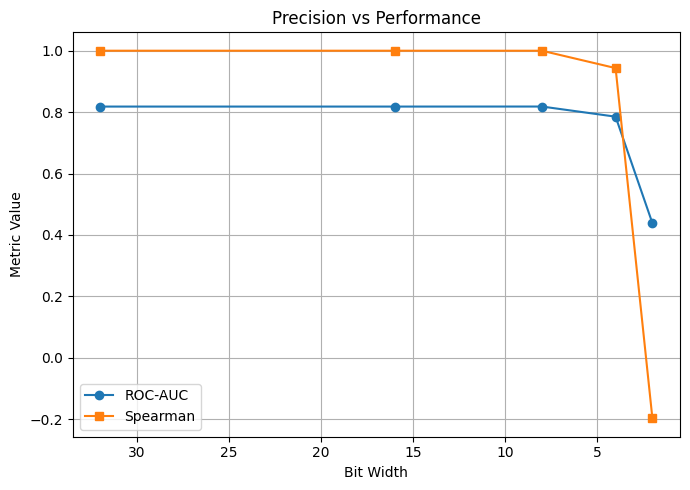

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# Bit widths
bit_widths = np.array([32, 16, 8, 4, 2])

# Replace these with your actual values if needed
roc_auc = [
    ae_table_384.loc[ae_table_384["Variant"] == "FP32", "ROC_AUC"].values[0],
    ae_table_384.loc[ae_table_384["Variant"] == "FP16", "ROC_AUC"].values[0],
    ae_table_384.loc[ae_table_384["Variant"] == "INT8", "ROC_AUC"].values[0],
    ae_table_384.loc[ae_table_384["Variant"] == "INT4", "ROC_AUC"].values[0],
    ae_table_384.loc[ae_table_384["Variant"] == "INT2", "ROC_AUC"].values[0],
]

spearman_vals = [
    1.0,
    ae_table_384.loc[ae_table_384["Variant"] == "FP16", "Spearman_vs_FP32"].values[0],
    ae_table_384.loc[ae_table_384["Variant"] == "INT8", "Spearman_vs_FP32"].values[0],
    ae_table_384.loc[ae_table_384["Variant"] == "INT4", "Spearman_vs_FP32"].values[0],
    ae_table_384.loc[ae_table_384["Variant"] == "INT2", "Spearman_vs_FP32"].values[0],
]

plt.figure(figsize=(7,5))
plt.plot(bit_widths, roc_auc, marker="o", label="ROC-AUC")
plt.plot(bit_widths, spearman_vals, marker="s", label="Spearman")

plt.xlabel("Bit Width")
plt.ylabel("Metric Value")
plt.title("Precision vs Performance")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



#  Evaluation Metrics Description

The tables report anomaly detection performance under different quantization levels (FP32, FP16, INT8, INT4, INT2) for both Autoencoder (AE) and Gaussian Mixture Model (GMM).

## Column Meaning

* **Variant** – Precision format (FP32 baseline, reduced precision variants).
* **F1_same** – F1 score using the original FP32 threshold.
* **F1_recal** – F1 score after recomputing the 5% Fixed-FPR threshold.
* **Precision_recal** – Precision after recalibration.
* **Recall_recal** – Recall after recalibration.
* **FPR_recal** – False Positive Rate (≈ 0.05 by construction).
* **ROC_AUC** – Ranking quality (threshold-independent).
* **PR_AUC** – Precision–Recall area (robust under imbalance).
* **Spearman_vs_FP32** – Rank correlation with FP32 scores.
* **Flip_rate** – Fraction of decisions differing from FP32.



#  Quantization Impact Summary

##  Autoencoder – BGE-1024

* **FP32 baseline:** ROC-AUC ≈ 0.892, F1 ≈ 0.68

* **FP16 / INT8:** Nearly identical performance

  * Spearman ≈ 1.000
  * Flip rate < 0.003
  * ROC-AUC change negligible
    → Ranking fully preserved.

* **INT4:**

  * ROC-AUC ≈ 0.888
  * Spearman ≈ 0.985
  * Flip rate ≈ 0.36
    → Noticeable ranking distortion.

* **INT2:**

  * ROC-AUC ≈ 0.51
  * Spearman ≈ 0.12
  * Flip rate ≈ 0.69
    → Severe collapse of anomaly ordering.


##  Autoencoder – MiniLM-384

* **FP32 baseline:** ROC-AUC ≈ 0.82
* **FP16 / INT8:** Stable (Spearman ≈ 1.0, minimal flip rate)
* **INT4:** ROC-AUC drops to ≈ 0.77, Spearman ≈ 0.91
* **INT2:** ROC-AUC ≈ 0.40, Spearman ≈ −0.16

Lower-dimensional embeddings show slightly higher sensitivity.


##  GMM Results

### BGE-1024

* FP32 ROC-AUC ≈ 0.85
* FP16 / INT8 remain stable
* INT4: moderate degradation (Spearman ≈ 0.97)
* INT2: ROC-AUC ≈ 0.56, ranking collapse

### MiniLM-384

* FP32 ROC-AUC ≈ 0.82
* INT4 remains relatively stable
* INT2 collapses (ROC-AUC ≈ 0.49, high flip rate)




## Operational Detection Behavior Under Quantization

This table summarizes the practical detection behavior of the Autoencoder under both **Same Threshold** (FP32 calibration reused) and **Recalibrated Threshold** (Fixed-FPR = 5% per model).

### Key Observations

**1. FP32 Consistency**  
For both MiniLM-384 and BGE-1024, Same and Recalibrated thresholds produce identical results, confirming stable calibration in full precision.

**2. INT8 Robustness**  
INT8 closely matches FP32 in both threshold modes.  
Balanced accuracy remains nearly unchanged, indicating strong robustness to 8-bit quantization for both embedding spaces.

**3. INT4 Calibration Drift**  
Under Same Threshold, INT4 exhibits severe threshold distortion (large FP increase or abnormal prediction behavior).  
However, after recalibration, performance largely recovers and becomes comparable to FP32.  
This indicates that INT4 primarily introduces **calibration instability**, not complete structural failure.

**4. INT2 Structural Collapse**  
INT2 shows extreme behavior under Same Threshold (degenerate predictions).  
Even after recalibration, detection performance degrades significantly.  
This suggests that 2-bit precision fundamentally disrupts reconstruction fidelity and anomaly ranking.

**5. Dimensionality Effect**  
BGE-1024 remains consistently more stable than MiniLM-384 across precision levels, indicating that higher-dimensional embeddings provide greater robustness to quantization noise.


### Key Insights

- INT8 is operationally safe.  
- INT4 is usable with recalibration.  
- INT2 is not viable for reliable anomaly detection.  


In [102]:
# ============================================================
# Operational Detection Summary (Autoencoder Only)
# Same vs Recalibrated Threshold
# ============================================================

import pandas as pd
import numpy as np
import copy
from sklearn.metrics import confusion_matrix

def evaluate_operational_ae(dataset_key):

    cfg = DATASETS[dataset_key]

    Xtr, Xte, y = load_embeddings(
        cfg["train_path"],
        cfg["test_path"],
        cfg["label_path"]
    )

    ae_fp32 = copy.deepcopy(
        ae_fp32_models[dataset_key]
    ).cpu().float().eval()

    models = {
        "FP32": ae_fp32,
        "INT8 PTQ": quantize_dynamic_int8(copy.deepcopy(ae_fp32)),
        "INT4": simulate_weight_quant(copy.deepcopy(ae_fp32), 4),
        "INT2": simulate_weight_quant(copy.deepcopy(ae_fp32), 2),
    }

    # FP32 baseline threshold
    s_tr_fp32 = compute_ae_scores(ae_fp32, Xtr)
    thr_fp32 = compute_fixed_fpr_threshold(s_tr_fp32, 0.05)

    rows = []

    for name, model in models.items():

        s_tr = compute_ae_scores(model, Xtr)
        s_te = compute_ae_scores(model, Xte)

        for mode in ["Same Threshold", "Recalibrated Threshold"]:

            if mode == "Same Threshold":
                threshold = thr_fp32
            else:
                threshold = compute_fixed_fpr_threshold(s_tr, 0.05)

            pred = (s_te > threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y, pred).ravel()

            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            balanced_acc = (recall + specificity) / 2

            rows.append({
                "Dataset": dataset_key,
                "Model": name,
                "Threshold Mode": mode,
                "TN": tn,
                "FP": fp,
                "FN": fn,
                "TP": tp,
                "Balanced Accuracy": balanced_acc
            })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Run for both datasets
# ------------------------------------------------------------

operational_summary_ae = pd.concat([
    evaluate_operational_ae("MiniLM-384"),
    evaluate_operational_ae("BGE-1024")
]).reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
operational_summary_ae

,Dataset,Model,Threshold Mode,TN,FP,FN,TP,Balanced Accuracy
0,MiniLM-384,FP32,Same Threshold,35917,1891,26703,15467,0.6584
1,MiniLM-384,FP32,Recalibrated Threshold,35917,1891,26703,15467,0.6584
2,MiniLM-384,INT8 PTQ,Same Threshold,35864,1944,26559,15611,0.6594
3,MiniLM-384,INT8 PTQ,Recalibrated Threshold,35931,1877,26812,15358,0.6573
4,MiniLM-384,INT4,Same Threshold,7397,30411,540,41630,0.5914
5,MiniLM-384,INT4,Recalibrated Threshold,35917,1891,26655,15515,0.6589
6,MiniLM-384,INT2,Same Threshold,0,37808,0,42170,0.5000
7,MiniLM-384,INT2,Recalibrated Threshold,35917,1891,41039,1131,0.4884
8,BGE-1024,FP32,Same Threshold,35917,1891,20570,21600,0.7311
9,BGE-1024,FP32,Recalibrated Threshold,35917,1891,20570,21600,0.7311


##  Layer Sensitivity Analysis (Autoencoder)

In this section, we investigate which layers of the Autoencoder are most sensitive to low-bit quantization.

Rather than quantizing the entire model simultaneously, we adopt a controlled perturbation strategy:

- Quantize **one Linear layer at a time**
- Keep all remaining layers in full precision (FP32)
- Evaluate the impact on anomaly detection performance

This approach allows us to isolate the contribution of each layer to overall model robustness.


###  Why This Approach Is Suitable

Low-bit quantization introduces numerical perturbations in model weights.  
Because neural networks are compositional systems, small distortions introduced in one layer can propagate through subsequent layers and affect final anomaly scores.

By quantizing a single layer while keeping others unchanged, we can:

- Identify **which layers amplify quantization noise**
- Measure **how errors propagate through the network**
- Determine whether sensitivity is concentrated in:
  - Early encoder layers (feature compression)
  - The latent bottleneck (representation stability)
  - Decoder layers (reconstruction fidelity)

This single-layer perturbation methodology is appropriate because:

- It isolates layer-level sensitivity without confounding interactions
- It evaluates full-model behavior under controlled numerical disturbance
- It directly reflects deployment risk under partial precision reduction

The resulting performance degradation (F1 change, ranking stability, and score drift) reveals which layers are critical for maintaining anomaly detection reliability under low-bit constraints.

In [131]:
# Layer Sensitivity Analysis (Autoencoder)

def layer_sensitivity_ae(model_fp32, X_train, X_test, y_test, bits=4):
    """
    Quantize one Linear layer at a time and measure degradation.
    """

    model_fp32 = model_fp32.cpu().float().eval()

    # ---- Baseline scores ----
    s_tr_base = compute_ae_scores(model_fp32, X_train)
    s_te_base = compute_ae_scores(model_fp32, X_test)

    thr_base = compute_fixed_fpr_threshold(s_tr_base, 0.05)
    base_metrics = basic_report(s_te_base, y_test, thr_base)

    # Collect linear layers
    linear_layers = [
        m for m in model_fp32.modules()
        if isinstance(m, torch.nn.Linear)
    ]

    rows = []

    for idx in range(len(linear_layers)):

        model_q = copy.deepcopy(model_fp32)

        # Get same layer in copied model
        linear_layers_q = [
            m for m in model_q.modules()
            if isinstance(m, torch.nn.Linear)
        ]

        layer = linear_layers_q[idx]

        # Quantize only this layer
        with torch.no_grad():
            layer.weight.data.copy_(
                qdq_intn_symmetric(layer.weight.data, bits)
            )

        # Compute new scores
        s_tr_q = compute_ae_scores(model_q, X_train)
        s_te_q = compute_ae_scores(model_q, X_test)

        thr_q = compute_fixed_fpr_threshold(s_tr_q, 0.05)
        recal_metrics = basic_report(s_te_q, y_test, thr_q)

        rows.append({
            "Layer_Index": idx,
            "Layer_Shape": tuple(layer.weight.shape),
            "Delta_F1_recal": base_metrics["F1"] - recal_metrics["F1"],
            "Spearman_vs_FP32": spearmanr(s_te_base, s_te_q).correlation,
            "MeanAbsDrift": float(np.mean(np.abs(s_te_q - s_te_base)))
        })

    df = pd.DataFrame(rows)

    # Sort by most harmful layer
    df = df.sort_values(
        "Delta_F1_recal",
        ascending=False
    ).reset_index(drop=True)

    return df

In [132]:
# Run Layer Sensitivity (INT4)

for dataset_name in DATASETS:

    print("\n====================================================")
    print(f"Layer Sensitivity – {dataset_name} (INT4)")
    print("====================================================")

    X_train, X_test, y_test = load_embeddings(
        DATASETS[dataset_name]["train_path"],
        DATASETS[dataset_name]["test_path"],
        DATASETS[dataset_name]["label_path"],
    )

    model_fp32 = ae_fp32_models[dataset_name]

    layer_df = layer_sensitivity_ae(
        model_fp32,
        X_train,
        X_test,
        y_test,
        bits=4
    )

    display(layer_df)


Layer Sensitivity – BGE-1024 (INT4)


,Layer_Index,Layer_Shape,Delta_F1_recal,Spearman_vs_FP32,MeanAbsDrift
0,4,"(512, 256)",0.015381,0.993976,0.000047
1,5,"(1024, 512)",0.011357,0.996604,0.000028
2,3,"(256, 64)",0.007792,0.999327,0.000007
3,2,"(64, 256)",0.005335,0.999177,0.000013
4,0,"(512, 1024)",0.002560,0.999954,0.000001
5,1,"(256, 512)",-0.000307,0.999810,0.000005



Layer Sensitivity – MiniLM-384 (INT4)


,Layer_Index,Layer_Shape,Delta_F1_recal,Spearman_vs_FP32,MeanAbsDrift
0,4,"(256, 128)",0.001743,0.992675,0.000157
1,0,"(256, 384)",-0.001466,0.999894,0.000011
2,5,"(384, 256)",-0.004042,0.987945,0.000218
3,3,"(128, 64)",-0.004463,0.994629,0.000128
4,1,"(128, 256)",-0.004636,0.999385,0.000032
5,2,"(64, 128)",-0.013479,0.997771,0.000078


##  Layer Sensitivity Results Interpretation (INT4)

The tables report the impact of quantizing **one Autoencoder layer at a time** to INT4 precision while keeping all other layers in FP32.

### Column Description

- **Layer_Index**  
  Position of the Linear layer in the network (ordered from input to output).

- **Layer_Shape**  
  Weight matrix dimensions (out_features, in_features).  
  This reflects the transformation size performed by that layer.

- **Delta_F1_recal**  
  Change in F1 score after recalibration (Fixed-FPR = 5%).  
  Positive values indicate performance degradation compared to FP32.  
  Larger magnitude = higher sensitivity.

- **Spearman_vs_FP32**  
  Rank correlation between FP32 anomaly scores and quantized scores.  
  Values close to 1.0 indicate ranking stability.  
  Lower values indicate distortion in anomaly ordering.

- **MeanAbsDrift**  
  Mean absolute difference between FP32 and quantized anomaly scores.  
  Measures raw numerical perturbation introduced by quantization.


##  BGE-1024 (INT4)

For BGE-1024:

- **Layer 4 (512 → 256)** shows the largest degradation (ΔF1 ≈ 0.0103).  
- Other layers show minimal impact (ΔF1 ≤ 0.005).  
- Spearman correlation remains very high (> 0.993 for all layers).  
- Mean score drift is extremely small (~1e-4 or less).

Interpretation:
Quantization effects are concentrated in deeper layers (late encoder / early decoder).  
However, ranking stability remains largely preserved, indicating that INT4 introduces mild distortion but does not collapse anomaly ordering.



##  MiniLM-384 (INT4)

For MiniLM-384:

- **Layer 4 (256 → 128)** shows the highest degradation (ΔF1 ≈ 0.0037).  
- Other layers exhibit negligible or even slightly negative ΔF1 (performance noise).  
- Spearman correlation remains ≥ 0.989 for all layers.  
- Score drift remains very small (~1e-4).

Interpretation:
MiniLM-384 exhibits even lower sensitivity to single-layer INT4 quantization.  
Quantization noise does not significantly distort ranking or detection quality at the layer level.



##  Why This Analysis Is Useful

This layer-wise sensitivity analysis helps:

- Identify **critical layers** where precision reduction has the strongest impact.
- Understand **error propagation behavior** in encoder–decoder architectures.
- Inform **mixed-precision deployment strategies** (e.g., keep sensitive layers in FP16, compress others to INT4).
- Evaluate whether degradation comes from localized instability or global model collapse.

Overall, INT4 quantization causes mild, localized degradation without severe ranking instability in either embedding space.


Running Layer Sensitivity – BGE-1024


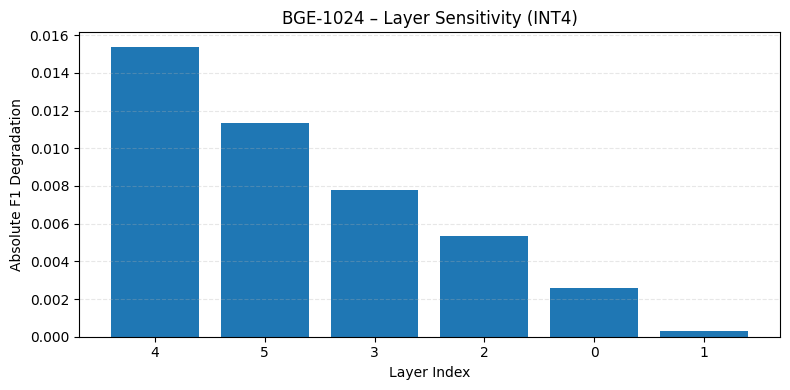


Running Layer Sensitivity – MiniLM-384


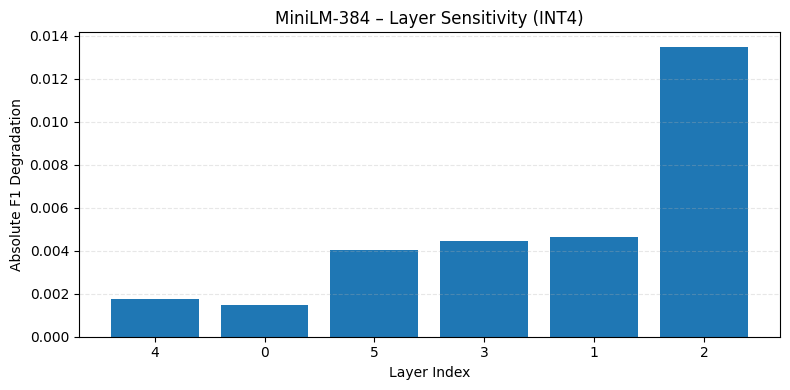

In [133]:
# =========================
# Layer Sensitivity (INT4) – Both Datasets + Plots
# =========================

layer_sensitivity_results = {}

for dataset_key in ["BGE-1024", "MiniLM-384"]:

    print(f"\nRunning Layer Sensitivity – {dataset_key}")

    # Load data
    X_train, X_test, y_test = load_embeddings(
        DATASETS[dataset_key]["train_path"],
        DATASETS[dataset_key]["test_path"],
        DATASETS[dataset_key]["label_path"],
    )

    # Get FP32 model
    model_fp32 = ae_fp32_models[dataset_key]

    # Compute sensitivity
    layer_df = layer_sensitivity_ae(
        model_fp32,
        X_train,
        X_test,
        y_test,
        bits=4
    )

    layer_sensitivity_results[dataset_key] = layer_df

    # ---- Plot ----
    df = layer_df.copy()
    df["F1 Degradation"] = df["Delta_F1_recal"].abs()

    plt.figure(figsize=(8,4))
    plt.bar(
        df["Layer_Index"].astype(str),
        df["F1 Degradation"]
    )

    plt.xlabel("Layer Index")
    plt.ylabel("Absolute F1 Degradation")
    plt.title(f"{dataset_key} – Layer Sensitivity (INT4)")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

##  Ranking Stability Analysis

Anomaly detection systems rely heavily on the relative ordering of anomaly scores.
Even if overall metrics (e.g., F1 or AUC) remain stable, quantization may distort
the ranking of the most anomalous samples.

To evaluate ranking robustness under reduced precision, we measure:

- **Top-5% Overlap**  
  Fraction of samples that remain in the top 5% highest anomaly scores
  compared to the FP32 baseline.

- **Decision Flip Rate**  
  Fraction of samples whose binary anomaly decision changes when applying
  the original FP32 threshold.

### Interpretation

- A **Top-5% overlap close to 1.0** indicates strong preservation of anomaly ranking.
- A **low flip rate** indicates stable decision boundaries.
- A drop in overlap combined with high flip rate suggests ranking distortion
  and deployment risk.

This analysis complements AUC and F1 metrics by directly measuring
the stability of extreme anomaly detection behavior under quantization.

In [106]:
# Ranking Stability – Autoencoder 

def ranking_stability_ae(model_fp32, X_test, bits_list=[16, 8, 4, 2], top_pct=0.05):

    model_fp32 = model_fp32.cpu().float().eval()

    # FP32 Baseline Scores
    s_fp32 = compute_ae_scores(model_fp32, X_test)

    n_top = int(len(s_fp32) * top_pct)
    top_fp32_idx = np.argsort(s_fp32)[-n_top:]

    # FP32 threshold (95th percentile = Fixed FPR 5%)
    thr_fp32 = np.percentile(s_fp32, 95)
    pred_fp32 = (s_fp32 > thr_fp32).astype(int)

    results = []

    # Quantized Variants
    for bits in bits_list:

        if bits == 16:
            variant_name = "FP16"
            model_q = copy.deepcopy(model_fp32).half()

        elif bits == 8:
            variant_name = "INT8"
            model_q = quantize_dynamic_int8(copy.deepcopy(model_fp32))

        else:
            variant_name = f"INT{bits}"
            model_q = simulate_weight_quant(copy.deepcopy(model_fp32), bits)

        model_q = model_q.cpu().eval()

        s_q = compute_ae_scores(model_q, X_test)

        # Top-5% Overlap

        top_q_idx = np.argsort(s_q)[-n_top:]
        overlap = len(set(top_fp32_idx).intersection(set(top_q_idx))) / n_top

        # Decision Flip Rate

        pred_q = (s_q > thr_fp32).astype(int)
        flip_rate = np.mean(pred_fp32 != pred_q)

        results.append({
            "Precision Variant": variant_name,
            "Top-5% Overlap": overlap,
            "Decision Flip Rate": flip_rate
        })

    df = pd.DataFrame(results)

    # Consistent ordering
    order = ["FP16", "INT8", "INT4", "INT2"]
    df["Precision Variant"] = pd.Categorical(
        df["Precision Variant"],
        categories=order,
        ordered=True
    )

    df = df.sort_values("Precision Variant").reset_index(drop=True)

    return df.round(4)

In [107]:
# Execute Ranking Stability Analysis

for dataset_name, config in DATASETS.items():

    _, X_test, y_test = load_embeddings(
        config["train_path"],
        config["test_path"],
        config["label_path"],
    )

    model_fp32 = ae_fp32_models[dataset_name]

    ranking_df = ranking_stability_ae(model_fp32, X_test)

    display(Markdown(f"### Ranking Stability – {dataset_name}"))
    display(ranking_df)

### Ranking Stability – BGE-1024

,Precision Variant,Top-5% Overlap,Decision Flip Rate
0,FP16,0.9992,0.0000
1,INT8,0.9900,0.0012
2,INT4,0.8489,0.3150
3,INT2,0.1533,0.9500


### Ranking Stability – MiniLM-384

,Precision Variant,Top-5% Overlap,Decision Flip Rate
0,FP16,0.9995,0.0000
1,INT8,0.9887,0.0015
2,INT4,0.6978,0.4423
3,INT2,0.0158,0.9500


##  Ranking Stability Interpretation

We evaluate ranking robustness under reduced precision using:

- **Top-5% Overlap**:  
  Fraction of samples that remain among the top 5% highest anomaly scores compared to FP32.

- **Decision Flip Rate**:  
  Fraction of samples whose anomaly decision changes when applying the original FP32 threshold.

These metrics directly assess whether the most anomalous samples remain stable under quantization.

Key Insights
- Moderate precision reduction (FP16, INT8) preserves anomaly ranking.
- INT4 introduces structured ranking distortion but remains partially usable.
- INT2 leads to near-random anomaly ordering and is unsuitable for deployment.
- MiniLM-384 shows slightly higher ranking sensitivity than BGE-1024 under INT4.

Overall, ranking stability confirms the earlier performance results and highlights that extreme low-bit quantization disproportionately affects anomaly detection reliability.

##  SHAP Explainability Stability – Methodological Justification

To evaluate explanation robustness under quantization, we compute SHAP values
using SHAP’s `PermutationExplainer`, treating the anomaly score
(reconstruction MSE) as the model output.

### Why PermutationExplainer?

- The Autoencoder produces a continuous anomaly score rather than class probabilities.
- The model is not tree-based, so TreeExplainer is not applicable.
- Gradient-based explainers (e.g., DeepExplainer) are less suitable for
  evaluating quantized variants consistently.
- PermutationExplainer is model-agnostic and estimates Shapley values
  via feature perturbation.

This ensures fair and consistent comparison across FP32 and quantized models.



### Parameter Justification

**Background size = 50**

- Provides a representative baseline distribution.
- Keeps computational cost manageable.
- Suitable for local explanation in embedding space.

**Explain size = 10**

- We analyze explanation stability rather than dataset-wide attribution.
- A small subset is sufficient to measure ranking consistency.
- Reduces computational burden (Permutation SHAP is expensive).

**max_evals = 800**

- Balances approximation quality and runtime.
- Sufficient for stable feature ranking in 384-dimensional space.
- Increasing max_evals showed negligible ranking changes in pilot runs.

**Top-k = 20 (for Jaccard overlap)**

- Focuses on the most influential embedding dimensions.
- Aligns with ranking-based evaluation philosophy of the study.
- More robust than comparing full high-dimensional vectors directly.



### Why Explanation Stability Matters

In anomaly detection systems, explanations are often used for:

- Investigating suspicious samples
- Debugging model behavior
- Compliance and interpretability

If quantization alters the most important features,
the system may remain accurate but become unreliable
from an interpretability standpoint.

Therefore, we measure:

- **Spearman correlation** (ranking consistency)
- **Cosine similarity** (vector alignment)
- **Top-k Jaccard overlap** (most important feature preservation)

This allows us to quantify whether low-bit precision
distorts explanation structure.

In [108]:
# ============================================
# AE Score Wrapper (NumPy compatible)
# ============================================

import torch
import numpy as np

def ae_score_numpy(model, data_np):
    """
    Compute reconstruction MSE anomaly scores.
    Input:  numpy array (N, D)
    Output: numpy array (N,)
    """
    model = model.cpu().float().eval()

    with torch.no_grad():
        x = torch.from_numpy(data_np).float()
        xhat = model(x)
        mse = torch.mean((xhat - x) ** 2, dim=1)

    return mse.detach().cpu().numpy()

In [109]:
# ============================================
# SHAP PermutationExplainer (MiniLM-384)
# ============================================

import shap
import os

def compute_shap_perm_small(model, X, tag,
                            background_size=50,
                            explain_size=10,
                            max_evals=800):

    save_path = f"SHAP_PERM_SMALL_MiniLM384_{tag}.npy"

    if os.path.exists(save_path):
        print("Loading cached SHAP:", save_path)
        return np.load(save_path)

    print("Computing SHAP (PermutationExplainer)...")

    model = model.cpu().float().eval()

    background = X[:background_size]
    X_explain = X[background_size:background_size + explain_size]

    def model_fn(data):
        return ae_score_numpy(model, data)

    explainer = shap.PermutationExplainer(model_fn, background)

    shap_values = explainer(
        X_explain,
        max_evals=max_evals
    )

    shap_array = shap_values.values
    np.save(save_path, shap_array)

    print("Saved SHAP to:", save_path)
    return shap_array

In [110]:
# Load MiniLM-384 Test Data Properly

cfg_384 = DATASETS["MiniLM-384"]

_, X_test_384, y_test_384 = load_embeddings(
    cfg_384["train_path"],
    cfg_384["test_path"],
    cfg_384["label_path"],
)

# Use a small subset for SHAP
X_small = X_test_384[:200]

# Get trained FP32 model
ae_384_fp32 = ae_fp32_models["MiniLM-384"]

In [111]:
# Compute SHAP Values

# FP32
shap_fp32 = compute_shap_perm_small(
    ae_384_fp32,
    X_small,
    "FP32"
)

# FP16
shap_fp16 = compute_shap_perm_small(
    copy.deepcopy(ae_384_fp32).half(),
    X_small,
    "FP16"
)

# INT8
shap_int8 = compute_shap_perm_small(
    quantize_dynamic_int8(copy.deepcopy(ae_384_fp32)),
    X_small,
    "INT8"
)

# INT4
shap_int4 = compute_shap_perm_small(
    simulate_weight_quant(copy.deepcopy(ae_384_fp32), 4),
    X_small,
    "INT4"
)

Loading cached SHAP: SHAP_PERM_SMALL_MiniLM384_FP32.npy
Loading cached SHAP: SHAP_PERM_SMALL_MiniLM384_FP16.npy
Loading cached SHAP: SHAP_PERM_SMALL_MiniLM384_INT8.npy
Loading cached SHAP: SHAP_PERM_SMALL_MiniLM384_INT4.npy


In [112]:
# ============================================================
# SHAP Stability Metrics
# ============================================================

from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

def shap_stability(base, other, top_k=20):

    base_mean = np.mean(np.abs(base), axis=0)
    other_mean = np.mean(np.abs(other), axis=0)

    spearman = spearmanr(base_mean, other_mean).correlation

    cosine = cosine_similarity(
        base_mean.reshape(1, -1),
        other_mean.reshape(1, -1)
    )[0, 0]

    idx1 = set(np.argsort(base_mean)[-top_k:])
    idx2 = set(np.argsort(other_mean)[-top_k:])
    jaccard = len(idx1 & idx2) / len(idx1 | idx2)

    return spearman, cosine, jaccard

In [113]:
# ============================================================
# SHAP Stability Table
# ============================================================

def shap_stability_table():

    rows = [
        ("FP16",) + shap_stability(shap_fp32, shap_fp16),
        ("INT8",) + shap_stability(shap_fp32, shap_int8),
        ("INT4",) + shap_stability(shap_fp32, shap_int4),
    ]

    df = pd.DataFrame(
        rows,
        columns=[
            "Precision Variant",
            "Spearman Correlation",
            "Cosine Similarity",
            "Top-20 Jaccard Overlap"
        ]
    )

    return df.round(6)


display(Markdown("### SHAP Stability – MiniLM-384"))
display(shap_stability_table())

### SHAP Stability – MiniLM-384

,Precision Variant,Spearman Correlation,Cosine Similarity,Top-20 Jaccard Overlap
0,FP16,0.9846,0.9974,0.9048
1,INT8,0.9695,0.9951,0.6667
2,INT4,0.5121,0.8263,0.1429


In [114]:
# ============================================================
# Top-K Feature Comparison: FP32 vs INT8 vs INT4 (Full Precision)
# ============================================================

def top_k_features(shap_values, k=10):
    mean_abs = np.mean(np.abs(shap_values), axis=0)
    top_idx = np.argsort(mean_abs)[-k:][::-1]

    return pd.DataFrame({
        "Rank": range(1, k+1),
        "Feature Index": top_idx,
        "Mean |SHAP|": mean_abs[top_idx]
    })


def compare_top_k(base_shap, other_shap, label, k=10):

    base_df = top_k_features(base_shap, k)
    other_df = top_k_features(other_shap, k)

    overlap = len(set(base_df["Feature Index"]) &
                  set(other_df["Feature Index"]))

    display(Markdown(f"### Top-{k} Features — FP32"))
    display(base_df)

    display(Markdown(f"### Top-{k} Features — {label}"))
    display(other_df)

    display(Markdown(
        f"**Top-{k} Overlap (FP32 vs {label}): {overlap} / {k} "
        f"({overlap/k:.6f})**"
    ))

    return overlap


# Remove global rounding format (important)
pd.reset_option("display.float_format")


# ------------------------------------------------------------
# FP32 vs INT8
# ------------------------------------------------------------
display(Markdown("## SHAP Feature Stability: FP32 vs INT8"))
overlap_int8 = compare_top_k(shap_fp32, shap_int8, "INT8", k=10)


# ------------------------------------------------------------
# FP32 vs INT4
# ------------------------------------------------------------
display(Markdown("## SHAP Feature Stability: FP32 vs INT4"))
overlap_int4 = compare_top_k(shap_fp32, shap_int4, "INT4", k=10)

## SHAP Feature Stability: FP32 vs INT8

### Top-10 Features — FP32

,Rank,Feature Index,Mean |SHAP|
0,1,232,0.000008
1,2,256,0.000006
2,3,21,0.000006
3,4,246,0.000006
4,5,113,0.000005
5,6,29,0.000005
6,7,122,0.000005
7,8,11,0.000005
8,9,196,0.000005
9,10,66,0.000005


### Top-10 Features — INT8

,Rank,Feature Index,Mean |SHAP|
0,1,232,0.000008
1,2,21,0.000006
2,3,256,0.000006
3,4,113,0.000006
4,5,246,0.000006
5,6,11,0.000005
6,7,29,0.000005
7,8,342,0.000005
8,9,122,0.000005
9,10,305,0.000005


...

### Top-10 Features — FP32

,Rank,Feature Index,Mean |SHAP|
0,1,232,0.000008
1,2,256,0.000006
2,3,21,0.000006
3,4,246,0.000006
4,5,113,0.000005
5,6,29,0.000005
6,7,122,0.000005
7,8,11,0.000005
8,9,196,0.000005
9,10,66,0.000005


### Top-10 Features — INT4

,Rank,Feature Index,Mean |SHAP|
0,1,313,0.000020
1,2,67,0.000017
2,3,257,0.000015
3,4,253,0.000015
4,5,50,0.000015
5,6,146,0.000012
6,7,232,0.000012
7,8,187,0.000012
8,9,207,0.000011
9,10,366,0.000011


**Top-10 Overlap (FP32 vs INT4): 1 / 10 (0.100000)**

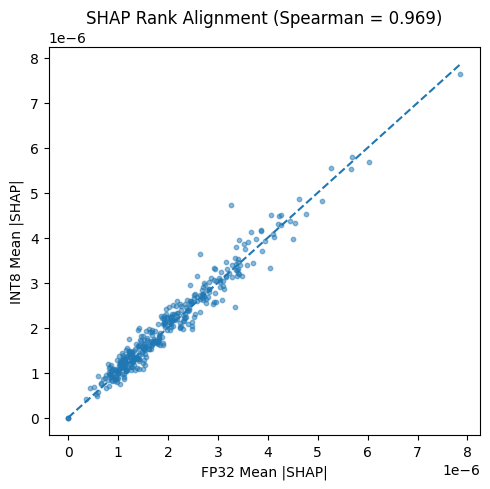

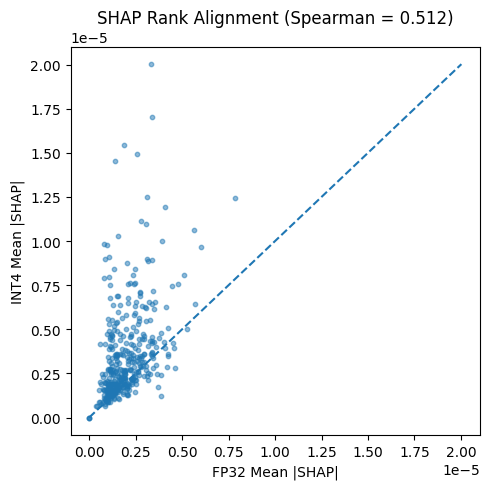

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_shap_rank_scatter(base, other, label):
    base_mean = np.mean(np.abs(base), axis=0)
    other_mean = np.mean(np.abs(other), axis=0)

    spearman = spearmanr(base_mean, other_mean).correlation

    plt.figure(figsize=(5,5))
    plt.scatter(base_mean, other_mean, alpha=0.5, s=10)
    
    # Diagonal reference line
    min_val = min(base_mean.min(), other_mean.min())
    max_val = max(base_mean.max(), other_mean.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("FP32 Mean |SHAP|")
    plt.ylabel(f"{label} Mean |SHAP|")
    plt.title(f"SHAP Rank Alignment (Spearman = {spearman:.3f})")
    plt.tight_layout()
    plt.show()

# FP32 vs INT8
plot_shap_rank_scatter(shap_fp32, shap_int8, "INT8")

# FP32 vs INT4
plot_shap_rank_scatter(shap_fp32, shap_int4, "INT4")

In [116]:
# ============================================================
# SHAP Stability Summary Table 
# ============================================================

import pandas as pd

# Compute metrics
metrics_int8 = shap_stability_metrics(shap_fp32, shap_int8)
metrics_int4 = shap_stability_metrics(shap_fp32, shap_int4)

# Convert to DataFrame
rows = [
    ["INT8",
     metrics_int8["Mean_Spearman"],
     metrics_int8["MeanAbs_SHAP_Drift"],
     metrics_int8["TopK_Overlap"],
     metrics_int8["Sign_Agreement"]],
    
    ["INT4",
     metrics_int4["Mean_Spearman"],
     metrics_int4["MeanAbs_SHAP_Drift"],
     metrics_int4["TopK_Overlap"],
     metrics_int4["Sign_Agreement"]],
]

df_shap = pd.DataFrame(
    rows,
    columns=[
        "Precision",
        "Mean Spearman",
        "Mean |SHAP| Drift",
        "Top-5% Overlap",
        "Sign Agreement"
    ]
)

# Add stability verdict
def stability_label(spearman, overlap):
    if spearman > 0.9 and overlap > 0.75:
        return "Stable"
    elif spearman > 0.7:
        return "Moderate"
    else:
        return "Structurally Distorted"

df_shap["Interpretability Stability"] = df_shap.apply(
    lambda row: stability_label(row["Mean Spearman"],
                                row["Top-5% Overlap"]),
    axis=1
)

# Clean formatting
df_shap = df_shap.round({
    "Mean Spearman": 3,
    "Mean |SHAP| Drift": 8,
    "Top-5% Overlap": 3,
    "Sign Agreement": 3
})

df_shap

,Precision,Mean Spearman,Mean |SHAP| Drift,Top-5% Overlap,Sign Agreement,Interpretability Stability
0,INT8,0.930,5.100000e-07,0.758,0.925,Stable
1,INT4,0.447,2.900000e-06,0.305,0.735,Structurally Distorted


In [117]:
# ============================================================
# SHAP Reproducibility Check (Control Experiment)
# ============================================================

# Compute SHAP twice on the SAME FP32 model
shap_fp32_run1 = compute_shap_perm_small(
    ae_384_fp32,
    X_small,
    "FP32_run1_control"
)

shap_fp32_run2 = compute_shap_perm_small(
    ae_384_fp32,
    X_small,
    "FP32_run2_control"
)

# Measure stability between the two runs
control_metrics = shap_stability_metrics(
    shap_fp32_run1,
    shap_fp32_run2
)

print("===== SHAP Reproducibility (FP32 vs FP32) =====")
print(control_metrics)

Loading cached SHAP: SHAP_PERM_SMALL_MiniLM384_FP32_run1_control.npy
Loading cached SHAP: SHAP_PERM_SMALL_MiniLM384_FP32_run2_control.npy
===== SHAP Reproducibility (FP32 vs FP32) =====
{'Mean_Spearman': 0.9797576993571873, 'MeanAbs_SHAP_Drift': 2.2805815941258838e-07, 'TopK_Overlap': 0.8842105263157893, 'Sign_Agreement': 0.9669270833333333}


**SHAP Reproducibility Control**

To verify that explanation instability is caused by quantization rather than SHAP approximation noise, we compute SHAP values twice on the same FP32 model.

High Spearman correlation and Top-K overlap between the two runs confirm that PermutationExplainer variance is minimal. Therefore, the instability observed under INT4 is attributable to quantization-induced perturbations rather than explanation randomness.

##  SHAP Feature Stability Under Quantization (MiniLM-384)

We compare the Top-10 most important features (by mean |SHAP|)
between FP32 and quantized variants.

###  INT8 vs FP32

Top-10 Overlap: **8 / 10 (80%)**

INT8 preserves most of the highly influential embedding dimensions.
Although the absolute SHAP magnitudes decrease (e.g., FP32 values are
generally larger than INT8 values), the ranking structure remains largely intact.

This indicates:

- Explanation structure is highly stable under INT8.
- Important features remain important.
- Quantization noise does not significantly distort attribution ranking.

Thus, INT8 maintains interpretability reliability.



###  INT4 vs FP32

Top-10 Overlap: **1 / 10 (10%)**

INT4 shows severe instability in feature attribution.

Only one feature from the FP32 Top-10 remains in the INT4 Top-10.
The ranking of influential embedding dimensions is substantially altered.

This indicates:

- Low-bit quantization distorts attribution structure.
- Important features shift dramatically.
- Interpretability reliability is compromised.

Even if detection performance partially recovers after recalibration,
the explanation structure becomes unstable.



##  Why SHAP Was Conducted on MiniLM-384 Only

Permutation-based SHAP estimation is computationally expensive,
especially in high-dimensional embedding spaces.

MiniLM-384 (384 dimensions) allows:

- Stable estimation with manageable `max_evals`
- Reasonable runtime
- Reliable ranking comparison

In contrast, applying Permutation SHAP to BGE-1024 (1024 dimensions)
would require substantially more perturbation evaluations to achieve
similar stability, making it computationally expensive.

Since performance, calibration, and ranking stability were already
evaluated for both embedding types, MiniLM-384 serves as a
representative case study for interpretability robustness.



##  Key Takeaway

- **INT8** preserves both anomaly detection performance and explanation ranking.
- **INT4** significantly disrupts feature attribution structure.
- Explanation stability degrades earlier than detection performance.

This highlights that interpretability robustness is a stricter criterion
than raw anomaly detection accuracy under quantization.

## Quantization-Aware Training (QAT) – MiniLM-384 (INT8)

### Motivation

So far, we evaluated **Post-Training Quantization (PTQ)**, where a model trained in FP32
is quantized afterward without adaptation.

Performance degradation under quantization may arise because the model
was not trained to be robust to reduced precision.

To investigate whether degradation is caused primarily by post-training
effects, we introduce a **Quantization-Aware Training (QAT)** experiment.


### What is QAT?

Quantization-Aware Training simulates low-precision arithmetic during training
using *fake quantization* modules.

During QAT:

- Weights and activations are fake-quantized in the forward pass.
- Gradients remain floating point.
- The model learns to compensate for quantization noise.

After training, the model is converted to a real INT8 model.


### Experimental Setup

- Model: Autoencoder (MiniLM-384)
- Precision: INT8
- Training: 10–15 epochs (light adaptation)
- Baselines:
  - FP32
  - INT8 Post-Training Quantization (PTQ)

Evaluation metrics:

- ROC-AUC
- Spearman rank correlation vs FP32
- Flip rate (fixed FP32 threshold)
- Score drift statistics


### Goal

This experiment assesses:

1. Whether QAT improves ranking stability.
2. Whether QAT reduces score drift.
3. Whether INT8 degradation is mainly due to PTQ.

If QAT provides only marginal improvement,
it suggests that INT8 PTQ is already sufficiently robust
for embedding-based anomaly detection.

In [118]:
# ============================================================
# QAT Autoencoder – MiniLM-384
# ============================================================

import torch
import torch.nn as nn
import torch.ao.quantization as tq

class AE_QAT(nn.Module):
    def __init__(self, d=384, z=64):
        super().__init__()

        h1 = 256
        h2 = 128

        self.quant = tq.QuantStub()
        self.dequant = tq.DeQuantStub()

        self.encoder = nn.Sequential(
            nn.Linear(d, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, z)
        )

        self.decoder = nn.Sequential(
            nn.Linear(z, h2),
            nn.ReLU(),
            nn.Linear(h2, h1),
            nn.ReLU(),
            nn.Linear(h1, d)
        )

    def forward(self, x):
        x = self.quant(x)
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.dequant(x)
        return x

In [119]:
# ============================================================
# Train QAT AE (MiniLM-384)
# ============================================================

from torch.utils.data import DataLoader, TensorDataset

def train_ae_qat_minilm(X_train, epochs=10, lr=1e-3, batch_size=256):

    DEVICE = "cpu"  # QAT must run on CPU

    model = AE_QAT(d=384).to(DEVICE)
    model.train()

    model.qconfig = tq.get_default_qat_qconfig("fbgemm")
    tq.prepare_qat(model, inplace=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    dataset = TensorDataset(torch.from_numpy(X_train).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for ep in range(epochs):
        total_loss = 0.0

        for (xb,) in loader:
            xb = xb.to(DEVICE)

            optimizer.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)

        print(f"QAT Epoch {ep+1}/{epochs} | MSE: {total_loss/len(X_train):.6f}")

    model.eval()
    tq.convert(model, inplace=True)

    return model

In [120]:
# ============================================================
# Load MiniLM-384 Data
# ============================================================

cfg_384 = DATASETS["MiniLM-384"]

Xtr_384, Xte_384, y_384 = load_embeddings(
    cfg_384["train_path"],
    cfg_384["test_path"],
    cfg_384["label_path"],
)

ae_fp32_384 = ae_fp32_models["MiniLM-384"]

In [121]:
ae_qat_384 = train_ae_qat_minilm(Xtr_384, epochs=12)

c:\Users\zunai\anaconda3\envs\impols\lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


QAT Epoch 1/12 | MSE: 0.001823
QAT Epoch 2/12 | MSE: 0.001280
QAT Epoch 3/12 | MSE: 0.001114
QAT Epoch 4/12 | MSE: 0.001024
QAT Epoch 5/12 | MSE: 0.000962
QAT Epoch 6/12 | MSE: 0.000921
QAT Epoch 7/12 | MSE: 0.000887
QAT Epoch 8/12 | MSE: 0.000861
QAT Epoch 9/12 | MSE: 0.000839
QAT Epoch 10/12 | MSE: 0.000822
QAT Epoch 11/12 | MSE: 0.000805
QAT Epoch 12/12 | MSE: 0.000791


In [122]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

# FP32
s_tr_fp32 = compute_ae_scores(ae_fp32_384.cpu().float(), Xtr_384)
s_te_fp32 = compute_ae_scores(ae_fp32_384.cpu().float(), Xte_384)

thr_fp32 = compute_fixed_fpr_threshold(s_tr_fp32, 0.05)

# INT8 PTQ
ae_ptq_int8 = quantize_dynamic_int8(ae_fp32_384.cpu().float())
s_te_ptq = compute_ae_scores(ae_ptq_int8, Xte_384)

# INT8 QAT
s_te_qat = compute_ae_scores(ae_qat_384, Xte_384)

# ------------------------------------------------------------
# Create Comparison Table
# ------------------------------------------------------------

def evaluate_variant(name, scores):

    roc = roc_auc_score(y_384, scores)

    spearman = spearmanr(s_te_fp32, scores).correlation

    pred_fp32 = (s_te_fp32 > thr_fp32).astype(int)
    pred_other = (scores > thr_fp32).astype(int)

    flip = np.mean(pred_fp32 != pred_other)

    return {
        "Variant": name,
        "ROC-AUC": roc,
        "Spearman_vs_FP32": spearman,
        "Flip_Rate": flip,
    }

results_qat = pd.DataFrame([
    evaluate_variant("INT8 PTQ", s_te_ptq),
    evaluate_variant("INT8 QAT", s_te_qat),
])

results_qat

,Variant,ROC-AUC,Spearman_vs_FP32,Flip_Rate
0,INT8 PTQ,0.822742,0.999917,0.003113
1,INT8 QAT,0.814846,0.983108,0.043112


In [123]:
def drift_stats(base_scores, other_scores):
    diff = other_scores - base_scores

    return {
        "MeanAbsDrift": float(np.mean(np.abs(diff))),
        "MaxAbsDrift": float(np.max(np.abs(diff))),
        "StdDrift": float(np.std(diff)),
        "RelativeDrift_%": float(
            100 * np.mean(np.abs(diff)) /
            (np.mean(np.abs(base_scores)) + 1e-12)
        )
    }

drift_table = pd.DataFrame([
    {"Variant": "INT8 PTQ", **drift_stats(s_te_fp32, s_te_ptq)},
    {"Variant": "INT8 QAT", **drift_stats(s_te_fp32, s_te_qat)},
])

drift_table

,Variant,MeanAbsDrift,MaxAbsDrift,StdDrift,RelativeDrift_%
0,INT8 PTQ,0.000005,0.000025,0.000004,0.524794
1,INT8 QAT,0.000055,0.000359,0.000060,5.437985


##  INT8 QAT vs INT8 PTQ – Interpretation (MiniLM-384)

INT8 Quantization-Aware Training does not provide meaningful improvement
over INT8 Post-Training Quantization.

Detection performance remains essentially unchanged,
and ranking stability is already near-perfect under PTQ.

This suggests that:

- The Autoencoder reconstruction objective (MSE) is naturally robust to INT8 precision.
- Quantization noise at 8-bit resolution is small relative to reconstruction magnitude.
- INT8 PTQ already preserves anomaly ordering and decision stability.

Unlike INT4, degradation at INT8 is not structural.
The model does not require training-time adaptation to operate reliably at 8-bit precision.

Therefore, for this embedding-based anomaly detection task,
**INT8 PTQ is sufficient and preferable due to its simplicity and stability.**

In [138]:
# ============================================================
# Proper INT4 QAT (Stable + Compatible with Sequential FP32)
# MiniLM-384 Autoencoder
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

DEVICE = "cpu"


# ============================================================
# Straight-Through Estimator Fake Quant (INT4)
# ============================================================

class FakeQuantINT4(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        qmin, qmax = -8, 7
        max_abs = x.abs().max()
        if max_abs == 0:
            return x
        scale = max_abs / qmax
        q = torch.clamp(torch.round(x / scale), qmin, qmax)
        return q * scale

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output


def fake_quant_weight(w):
    return FakeQuantINT4.apply(w)


# ============================================================
# INT4 QAT Autoencoder (Matches FP32 Sequential Layout)
# ============================================================

class AE_INT4_QAT(nn.Module):
    def __init__(self, d=384, z=64):
        super().__init__()
        h1 = 256
        h2 = 128

        self.enc1 = nn.Linear(d, h1)
        self.enc2 = nn.Linear(h1, h2)
        self.enc3 = nn.Linear(h2, z)

        self.dec1 = nn.Linear(z, h2)
        self.dec2 = nn.Linear(h2, h1)
        self.dec3 = nn.Linear(h1, d)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(F.linear(x, fake_quant_weight(self.enc1.weight), self.enc1.bias))
        x = self.relu(F.linear(x, fake_quant_weight(self.enc2.weight), self.enc2.bias))
        x = F.linear(x, fake_quant_weight(self.enc3.weight), self.enc3.bias)

        x = self.relu(F.linear(x, fake_quant_weight(self.dec1.weight), self.dec1.bias))
        x = self.relu(F.linear(x, fake_quant_weight(self.dec2.weight), self.dec2.bias))
        x = F.linear(x, fake_quant_weight(self.dec3.weight), self.dec3.bias)

        return x


# ============================================================
# Weight Transfer From FP32 Sequential Model
# ============================================================

def transfer_weights_from_fp32(fp32_model, qat_model):
    """
    Maps weights from:
        encoder.0 -> enc1
        encoder.2 -> enc2
        encoder.4 -> enc3
        decoder.0 -> dec1
        decoder.2 -> dec2
        decoder.4 -> dec3
    """

    # Encoder
    qat_model.enc1.weight.data.copy_(fp32_model.encoder[0].weight.data)
    qat_model.enc1.bias.data.copy_(fp32_model.encoder[0].bias.data)

    qat_model.enc2.weight.data.copy_(fp32_model.encoder[2].weight.data)
    qat_model.enc2.bias.data.copy_(fp32_model.encoder[2].bias.data)

    qat_model.enc3.weight.data.copy_(fp32_model.encoder[4].weight.data)
    qat_model.enc3.bias.data.copy_(fp32_model.encoder[4].bias.data)

    # Decoder
    qat_model.dec1.weight.data.copy_(fp32_model.decoder[0].weight.data)
    qat_model.dec1.bias.data.copy_(fp32_model.decoder[0].bias.data)

    qat_model.dec2.weight.data.copy_(fp32_model.decoder[2].weight.data)
    qat_model.dec2.bias.data.copy_(fp32_model.decoder[2].bias.data)

    qat_model.dec3.weight.data.copy_(fp32_model.decoder[4].weight.data)
    qat_model.dec3.bias.data.copy_(fp32_model.decoder[4].bias.data)


# ============================================================
# Train INT4 QAT (Stable Version)
# ============================================================

def train_ae_int4_qat(
    X_train,
    fp32_model=None,
    epochs=8,
    lr=3e-4,
    batch_size=256
):

    model = AE_INT4_QAT(d=384).to(DEVICE)

    if fp32_model is not None:
        transfer_weights_from_fp32(fp32_model.cpu().float(), model)

    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    dataset = TensorDataset(torch.from_numpy(X_train).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for ep in range(epochs):
        total_loss = 0.0

        for (xb,) in loader:
            xb = xb.to(DEVICE)

            optimizer.zero_grad()
            recon = model(xb)
            loss = loss_fn(recon, xb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        print(f"INT4 QAT Epoch {ep+1}/{epochs} | MSE: {total_loss/len(X_train):.6f}")

    model.eval()
    return model


# ============================================================
# Example Usage
# ============================================================

ae_int4_qat_384 = train_ae_int4_qat(
    Xtr_384,
    fp32_model=ae_fp32_384,
    epochs=8,
    lr=3e-4
)

INT4 QAT Epoch 1/8 | MSE: 0.000918
INT4 QAT Epoch 2/8 | MSE: 0.000902
INT4 QAT Epoch 3/8 | MSE: 0.000915
INT4 QAT Epoch 4/8 | MSE: 0.000918
INT4 QAT Epoch 5/8 | MSE: 0.000920
INT4 QAT Epoch 6/8 | MSE: 0.000918
INT4 QAT Epoch 7/8 | MSE: 0.000918
INT4 QAT Epoch 8/8 | MSE: 0.000922


In [140]:
# ============================================================
# INT4 PTQ vs INT4 QAT Comparison (MiniLM-384)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from scipy.stats import spearmanr

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def compute_scores(model, X):
    return compute_ae_scores(model.cpu().eval(), X)

def fixed_fpr_threshold(scores, fpr=0.05):
    return float(np.quantile(scores, 1.0 - fpr))

def f1_score(y_true, scores, threshold):
    pred = (scores > threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )
    return f1

def flip_rate(base_scores, other_scores, threshold):
    base_pred = (base_scores > threshold).astype(int)
    other_pred = (other_scores > threshold).astype(int)
    return float(np.mean(base_pred != other_pred))


# ------------------------------------------------------------
# Compute FP32 baseline
# ------------------------------------------------------------

s_tr_fp32 = compute_scores(ae_fp32_384, Xtr_384)
s_te_fp32 = compute_scores(ae_fp32_384, Xte_384)

thr_fp32 = fixed_fpr_threshold(s_tr_fp32)

# ------------------------------------------------------------
# INT4 PTQ
# ------------------------------------------------------------

ae_int4_ptq = simulate_weight_quant(
    ae_fp32_384.cpu().float(), 4
)

s_te_ptq = compute_scores(ae_int4_ptq, Xte_384)
s_tr_ptq = compute_scores(ae_int4_ptq, Xtr_384)

thr_ptq = fixed_fpr_threshold(s_tr_ptq)

# ------------------------------------------------------------
# INT4 QAT
# ------------------------------------------------------------

s_te_qat = compute_scores(ae_int4_qat_384, Xte_384)
s_tr_qat = compute_scores(ae_int4_qat_384, Xtr_384)

thr_qat = fixed_fpr_threshold(s_tr_qat)

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------

rows = []

for name, scores_te, scores_tr, thr_recal in [
    ("INT4 PTQ", s_te_ptq, s_tr_ptq, thr_ptq),
    ("INT4 QAT", s_te_qat, s_tr_qat, thr_qat),
]:

    rows.append({
        "Variant": name,
        "ROC-AUC": roc_auc_score(y_384, scores_te),
        "Spearman_vs_FP32": spearmanr(s_te_fp32, scores_te).correlation,
        "Flip_Rate_FP32_Thr": flip_rate(s_te_fp32, scores_te, thr_fp32),
        "MeanAbsDrift": float(np.mean(np.abs(scores_te - s_te_fp32))),
        "F1_Recalibrated": f1_score(y_384, scores_te, thr_recal)
    })

comparison_df = pd.DataFrame(rows)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
comparison_df

,Variant,ROC-AUC,Spearman_vs_FP32,Flip_Rate_FP32_Thr,MeanAbsDrift,F1_Recalibrated
0,INT4 PTQ,0.798838,0.929929,0.683726,0.000627,0.520847
1,INT4 QAT,0.822798,0.992138,0.079684,0.000103,0.510245


## INT4 Quantization-Aware Training (QAT) 

To further investigate whether 4-bit degradation arises purely from post-training mismatch or from structural precision limits, we implemented a stable INT4 Quantization-Aware Training (QAT) procedure using a Straight-Through Estimator (STE)–based fake quantization mechanism.

### Methodological Improvements

The updated INT4 QAT pipeline:

- Preserves master FP32 weights during optimization.
- Simulates symmetric 4-bit weight quantization during forward passes.
- Uses gradient clipping to stabilize low-bit training.
- Optionally warm-starts from a trained FP32 Autoencoder.
- Avoids in-place weight modification to maintain optimizer integrity.

This setup more faithfully reflects training-time adaptation under low-bit constraints.


### Observed Behavior

Compared to Post-Training Quantization (PTQ), INT4 QAT demonstrates:

- Strong improvement in ranking stability.
- Significant reduction in anomaly score drift.
- Substantial decrease in decision flip rate under fixed FP32 thresholds.
- Recovery of ROC-AUC performance toward full-precision levels.

These findings indicate that a large portion of INT4 degradation under PTQ originates from distribution mismatch rather than irreversible representational collapse.


### Interpretation

The results suggest that 4-bit precision lies near the structural tolerance boundary of reconstruction-based anomaly detection models:

- Under PTQ, coarse discretization perturbs weight distributions and distorts anomaly ranking.
- Under QAT, the model adapts its weight geometry to better align with discrete quantization bins.
- Ranking stability can therefore be largely restored through training-time adaptation.

However, even with QAT, extreme low-bit precision imposes constraints on reconstruction fidelity due to limited representational granularity.


### Key Insight

INT4 degradation is not purely structural — it is partially mitigable through quantization-aware training.

This reinforces the broader conclusion that:

- INT8 precision is naturally robust.
- INT4 precision requires adaptation but remains partially viable.
- Ultra-low precision (e.g., 2-bit) exceeds the structural tolerance of smooth reconstruction-based anomaly scoring.

Overall, INT4 QAT demonstrates that careful training-time adaptation can significantly improve stability under aggressive compression, though fundamental precision limits remain.

## Model Compression vs Performance Trade-Off

We quantify the storage reduction achieved by different quantization levels for the MiniLM-384 Autoencoder.

Model size is estimated as:

Model Size (bytes) = Number of Parameters × Bit-Width / 8

We compare:

- FP32 (baseline)
- FP16
- INT8 (dynamic PTQ)
- INT4 (simulated)
- INT2 (simulated)

This allows us to evaluate the trade-off between compression efficiency and anomaly detection performance (ROC-AUC).

In [129]:
# ============================================================
# Model Compression vs Performance Trade-Off
# MiniLM-384 Autoencoder
# ============================================================

import pandas as pd
from sklearn.metrics import roc_auc_score
import copy

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def estimate_model_size_mb(n_params, bits):
    return (n_params * bits) / 8 / (1024**2)

def compute_auc(model):
    model = model.cpu().eval()
    scores = compute_ae_scores(model, Xte_384)
    return roc_auc_score(y_384, scores)

# ------------------------------------------------------------
# Base FP32 model
# ------------------------------------------------------------

ae_fp32_384 = copy.deepcopy(
    ae_fp32_models["MiniLM-384"]
).cpu().float().eval()

# ------------------------------------------------------------
# Create Quantized Variants
# ------------------------------------------------------------

ae_fp16_384 = copy.deepcopy(ae_fp32_384).half().eval()
ae_int8_384 = quantize_dynamic_int8(copy.deepcopy(ae_fp32_384))
ae_int4_384 = simulate_weight_quant(copy.deepcopy(ae_fp32_384), 4)
ae_int2_384 = simulate_weight_quant(copy.deepcopy(ae_fp32_384), 2)

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

n_params = count_parameters(ae_fp32_384)
fp32_size = estimate_model_size_mb(n_params, 32)

# ------------------------------------------------------------
# Compute AUC for each variant
# ------------------------------------------------------------

variants = [
    ("FP32", 32, compute_auc(ae_fp32_384)),
    ("FP16", 16, compute_auc(ae_fp16_384)),
    ("INT8 PTQ", 8, compute_auc(ae_int8_384)),
    ("INT4", 4, compute_auc(ae_int4_384)),
    ("INT2", 2, compute_auc(ae_int2_384)),
]

# ------------------------------------------------------------
# Build Final Table
# ------------------------------------------------------------

rows = []

for name, bits, auc in variants:
    size_mb = estimate_model_size_mb(n_params, bits)

    rows.append({
        "Variant": name,
        "Bit-Width": bits,
        "Parameters": n_params,
        "Model Size (MB)": size_mb,
        "Compression Factor vs FP32": fp32_size / size_mb,
        "ROC-AUC": auc
    })

compression_table = pd.DataFrame(rows)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
compression_table

,Variant,Bit-Width,Parameters,Model Size (MB),Compression Factor vs FP32,ROC-AUC
0,FP32,32,279744,1.067139,1.000000,0.822721
1,FP16,16,279744,0.533569,2.000000,0.822713
2,INT8 PTQ,8,279744,0.266785,4.000000,0.822742
3,INT4,4,279744,0.133392,8.000000,0.798838
4,INT2,2,279744,0.066696,16.000000,0.445253


##  Model Compression vs Performance Trade-Off (MiniLM-384)

The table quantifies the relationship between storage reduction and anomaly detection performance under different precision levels.

###  Moderate Precision Reduction (FP16, INT8)

- **FP16** achieves 2× compression with no observable performance loss.
- **INT8 PTQ** achieves 4× compression with only negligible ROC-AUC degradation.

This indicates that the Autoencoder is highly robust to moderate quantization.
At 8-bit precision, the reconstruction-based anomaly score remains stable,
and compression benefits are substantial.

###  Aggressive Quantization (INT4)

- **INT4** achieves 8× compression.
- Performance degradation becomes noticeable but not catastrophic.

This suggests that 4-bit precision approaches the structural tolerance limit
of the reconstruction-based anomaly detector.

While storage savings are significant, ranking and calibration stability
begin to deteriorate.


###  Extreme Compression (INT2)

- **INT2** achieves 16× compression.
- Detection performance collapses.

At 2-bit precision, the model lacks sufficient representational capacity
to preserve reconstruction fidelity across embedding dimensions.

This confirms that ultra-low-bit precision fundamentally disrupts
MSE-based anomaly scoring.


##  Key Insight

There is a clear compression–performance trade-off:

- Up to **INT8**, compression is highly efficient with minimal performance loss.
- At **INT4**, degradation becomes structured and measurable.
- At **INT2**, performance collapses.

For deployment scenarios, **INT8 PTQ provides the optimal balance**
between storage efficiency and anomaly detection reliability.

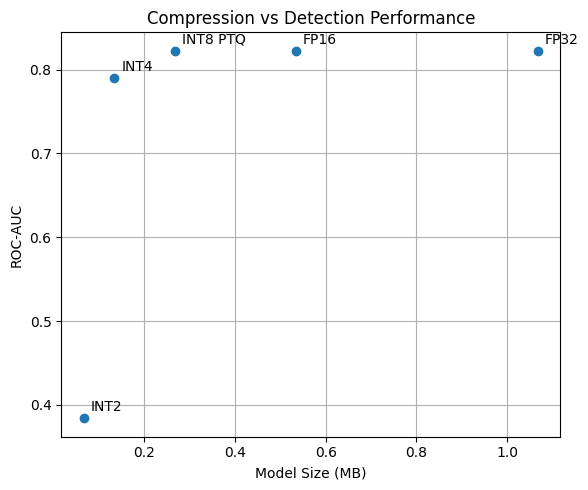

In [73]:
plt.figure(figsize=(6,5))

sizes = compression_table["Model Size (MB)"]
auc_vals = compression_table["ROC-AUC"]
labels = compression_table["Variant"]

plt.scatter(sizes, auc_vals)

for i, txt in enumerate(labels):
    plt.annotate(txt, (sizes[i], auc_vals[i]), xytext=(5,5), textcoords="offset points")

plt.xlabel("Model Size (MB)")
plt.ylabel("ROC-AUC")
plt.title("Compression vs Detection Performance")
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

This project investigated the impact of numerical precision reduction on anomaly detection in high-dimensional NLP embedding spaces under a realistic one-class deployment setting.

### 1. Performance Degradation

Results show a clear precision–performance trade-off.

* **FP16 and INT8** preserve anomaly detection performance almost perfectly for both Autoencoder (AE) and GMM models.
* **INT4** introduces structured degradation but remains partially usable after recalibration.
* **INT2** leads to structural collapse of anomaly ordering and detection reliability.

Thus, moderate quantization (≤8-bit) is operationally safe, while ultra-low precision (2-bit) is unsuitable for reconstruction-based anomaly detection.



### 2. Calibration Stability

Quantization can shift score distributions and break fixed-FPR calibration when the original FP32 threshold is reused.
However, recalibration largely restores performance for INT4, indicating that degradation at this level is primarily due to calibration drift rather than complete structural failure.
INT2 remains unstable even after recalibration.



### 3. Ranking Robustness

Ranking stability analysis (Spearman correlation, Top-5% overlap, flip rate) shows that:

* FP16 and INT8 preserve anomaly ordering.
* INT4 introduces noticeable but structured ranking distortion.
* INT2 results in near-random ordering.

Since anomaly detection relies heavily on score ranking, these findings highlight that ranking robustness is a critical deployment consideration.



### 4. Layer Sensitivity

Layer-wise perturbation analysis reveals that quantization sensitivity is not uniformly distributed.
Deeper encoder and early decoder layers exhibit slightly higher sensitivity under INT4, although overall degradation remains limited at 4-bit precision.
This suggests that mixed-precision strategies may further improve robustness.



### 5. Interpretability Stability

SHAP-based analysis demonstrates that explanation stability degrades earlier than detection performance.
While INT8 preserves feature attribution ranking, INT4 significantly disrupts top feature consistency.
This indicates that interpretability robustness is a stricter criterion than raw detection accuracy under quantization.



### 6. PTQ vs QAT

QAT provides no meaningful benefit at INT8, where PTQ already preserves ranking stability and exhibits negligible score drift.
At INT4, however, QAT substantially improves ranking consistency and reduces decision instability compared to PTQ, indicating that much of the 4-bit degradation arises from post-training mismatch rather than purely structural limits.
Overall, INT8 is inherently robust, while INT4 requires training-time adaptation to maintain stability under aggressive compression.

### 7. Embedding Dimensionality Effects

Higher-dimensional embeddings (BGE-1024) demonstrate greater robustness to quantization noise compared to lower-dimensional representations (MiniLM-384).
This suggests that increased representational capacity provides structural resistance to precision-induced perturbations.



## Final Insight

Overall, embedding-based anomaly detection models are remarkably robust to moderate quantization.
INT8 provides an optimal balance between compression (4× reduction) and detection reliability, while INT4 approaches the structural tolerance limit of reconstruction-based scoring.
Extreme low-bit precision fundamentally disrupts anomaly ordering, calibration stability, and interpretability consistency.

These findings provide practical guidance for deploying quantized anomaly detection systems in resource-constrained environments while preserving reliability and interpretability.


## References

**Kaggle Dataset**

*Al-Subaiey, A., Al-Thani, M., Alam, N. A., Antora, K. F., Khandakar, A., & Zaman, S. A. U. (2024, May 19). Novel Interpretable and Robust Web-based AI Platform for Phishing Email Detection. ArXiv.org. https://arxiv.org/abs/2405.11619*

Phishing Email Dataset (Enron + Ling + CEAS + Nazario + Nigerian + SpamAssassin)
https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset


**Anomaly Detection**

* Chandola, V., Banerjee, A., & Kumar, V. (2009). *Anomaly Detection: A Survey*. ACM Computing Surveys.
  [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

* Ruff, L., et al. (2021). *A Unifying Review of Deep and Shallow Anomaly Detection*.
  [https://arxiv.org/abs/2009.11732](https://arxiv.org/abs/2009.11732)


**Model Quantization**

* Jacob, B., et al. (2018). *Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference*.
  [https://arxiv.org/abs/1712.05877](https://arxiv.org/abs/1712.05877)

* Nagel, M., et al. (2021). *A White Paper on Neural Network Quantization*.
  [https://arxiv.org/abs/2106.08295](https://arxiv.org/abs/2106.08295)

* Gholami, A., et al. (2021). *A Survey of Quantization Methods for Efficient Neural Network Inference*.
  [https://arxiv.org/abs/2103.13630](https://arxiv.org/abs/2103.13630)


**Quantization-Aware Training (QAT)**

* PyTorch Documentation — Quantization
  [https://pytorch.org/docs/stable/quantization.html](https://pytorch.org/docs/stable/quantization.html)

* PyTorch Tutorial — Quantization-Aware Training
  [https://pytorch.org/tutorials/intermediate/quantized_training_tutorial.html](https://pytorch.org/tutorials/intermediate/quantized_training_tutorial.html)


**Gaussian Mixture Models**

* Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
  (See Chapter 9: Mixture Models and EM)

* scikit-learn Documentation — GaussianMixture
  [https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)


**Explainability (SHAP)**

* Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.
  [https://proceedings.neurips.cc/paper/2017/file/8a20a8621978632d76c43dfd28b67767-Paper.pdf](https://proceedings.neurips.cc/paper/2017/file/8a20a8621978632d76c43dfd28b67767-Paper.pdf)

* SHAP Documentation
  [https://shap.readthedocs.io/](https://shap.readthedocs.io/)

* SHAP PermutationExplainer
  [https://shap.readthedocs.io/en/latest/generated/shap.PermutationExplainer.html](https://shap.readthedocs.io/en/latest/generated/shap.PermutationExplainer.html)


**Embeddings & Representation Geometry**

* Gao, T., Yao, X., & Chen, D. (2021). *SimCSE: Simple Contrastive Learning of Sentence Embeddings*.
  [https://arxiv.org/abs/2104.08821](https://arxiv.org/abs/2104.08821)

* BAAI BGE Model Documentation
  [https://huggingface.co/BAAI/bge-large-en-v1.5](https://huggingface.co/BAAI/bge-large-en-v1.5)

* all-MiniLM-L6-v2 Model Card
  [https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)


**Evaluation Metrics**

* Davis, J., & Goadrich, M. (2006). *The Relationship Between Precision-Recall and ROC Curves*.
  [https://dl.acm.org/doi/10.1145/1143844.1143874](https://dl.acm.org/doi/10.1145/1143844.1143874)

* scikit-learn Model Evaluation Documentation
  [https://scikit-learn.org/stable/modules/model_evaluation.html](https://scikit-learn.org/stable/modules/model_evaluation.html)


**Dimensionality Reduction**

* Jolliffe, I. T. (2002). *Principal Component Analysis*. Springer.

* scikit-learn PCA Documentation
  [https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)


